<div style="border-left: 5px solid #1f4e79; padding: 16px 20px; background-color: #f8fafc; border: 1px solid #d9e2ec; border-radius: 6px; margin-bottom: 24px; font-family: Arial, sans-serif;">
  <h1 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 28px;">Notebook 14 — Démonstration réelle -  Paris & 10 grandes métropoles</h1>
  <p style="margin: 0; color: #4b5563; font-size: 15px; line-height: 1.55;">Ce notebook constitue la preuve de fonctionnement métier du modèle de valorisation immobilière augmentée. Il démontre la réutilisation du modèle final du notebook 12, la contextualisation locale à partir d’une adresse réelle, le recentrage des comparables, la lisibilité des indicateurs de performance (R², MAE, RMSE) et la comparaison transparente entre métropoles.</p>
</div>

In [ ]:
#importations

# Désactive les avertissements non bloquants afin d'alléger la lecture
# des sorties du notebook.
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML, clear_output

# Métriques utilisées pour évaluer les performances du modèle.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Fonction de découpage apprentissage / test.
from sklearn.model_selection import train_test_split


# Chargement optionnel de joblib.
# Utilisé pour sauvegarder ou recharger les modèles entraînés.
try:
    import joblib
except Exception:
    joblib = None
    print("joblib indisponible. Installer avec : pip install joblib")


# Chargement optionnel de requests.
# Utilisé pour le géocodage d'une adresse saisie par l'utilisateur.
try:
    import requests
except Exception:
    requests = None
    print("requests indisponible. Le géocodage adresse sera désactivé.")


# Chargement optionnel de Folium.
# Permet la génération des cartes interactives.
try:
    import folium
    from folium.plugins import MarkerCluster
except Exception:
    folium = None
    MarkerCluster = None
    print("folium indisponible. Installer avec : pip install folium")


# Chargement optionnel des widgets interactifs Jupyter.
# Ils sont utilisés pour construire le démonstrateur.
try:
    import ipywidgets as widgets
    from ipywidgets import Layout, HBox, VBox
except Exception:
    widgets = None
    print("ipywidgets indisponible. Installer avec : pip install ipywidgets")


# Paramètres d'affichage des tableaux pandas.
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 120)


# Nom du projet.
# Permet de retrouver automatiquement la racine du dépôt.
PROJECT_NAME = "SYSTEME_AIDE_DECISION_IMMOBILIERE"

CURRENT_DIR = Path.cwd().resolve()


# Recherche automatique du dossier racine du projet.
# Le notebook peut être exécuté depuis différents répertoires.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = next(
        (p for p in [CURRENT_DIR, *CURRENT_DIR.parents] if p.name == PROJECT_NAME),
        CURRENT_DIR,
    )


# Dossier de sortie du démonstrateur.
# Les résultats produits seront enregistrés dans ce répertoire.
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "demo_paris_metropoles"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Paramètres métier communs au projet.

# Borne maximale retenue pour le prix au m².
PRIX_M2_MAX_METIER = 45_000

# Nom de la cible transformée.
TARGET_LOG = "log_prix_m2"

# Nom de la cible exprimée en euros par m².
TARGET_RAW = "prix_m2"

# Graine aléatoire utilisée pour garantir la reproductibilité.
RANDOM_STATE = 42


# Vérification des chemins utilisés par le notebook.
print("PROJECT_ROOT :", PROJECT_ROOT)
print("OUTPUT_DIR   :", OUTPUT_DIR)
```

Cette version est cohérente avec le niveau de documentation de tes notebooks 11 à 14 : les commentaires expliquent **le rôle** de chaque bloc sans tomber dans des explications trop élémentaires. C'est un bon compromis entre lisibilité, maintenance et qualité professionnelle.


PROJECT_ROOT : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE
OUTPUT_DIR   : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\demo_paris_metropoles


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Section</h3>
  <div style="color: #4b5563; font-size: 14px;">Artefacts attendus Cette cellule vérifie les sorties canoniques des notebooks amont : feature store et contrats (notebook 11), modèle final joblib (notebook 12) et synthèse de référence (notebook 13). L’exécution doit s’arrêter explicitement si les données réelles obligatoires sont absentes.</div>
</div>

In [ ]:
Voici une version commentée dans le même style que tes autres notebooks.

```python
# Emplacements de référence des principaux artefacts produits
# par les notebooks de préparation et de modélisation.
# Ces chemins correspondent à l'organisation standard du projet.

CANONICAL = {
    "dataset": PROJECT_ROOT / "outputs" / "feature_store_modelisation_taux" / "tables" / "dataset_modelisation_selected_taux.parquet",
    "feature_blocks": PROJECT_ROOT / "outputs" / "feature_store_modelisation_taux" / "config" / "feature_blocks_selected_taux.json",
    "scenario_features": PROJECT_ROOT / "outputs" / "feature_store_modelisation_taux" / "config" / "scenario_features_taux.json",
    "manifest": PROJECT_ROOT / "outputs" / "feature_store_modelisation_taux" / "config" / "feature_store_manifest_taux.json",
    "model": PROJECT_ROOT / "outputs" / "modelisation_prix_m2_taux_max_45000" / "models" / "modele_final_pipeline.joblib",
    "synthese_13": PROJECT_ROOT / "outputs" / "synthese_resultats_taux_alignee_notebook_12" / "tables" / "synthese_finale_apport_pipeline_taux.csv",
}


# Répertoires explorés automatiquement si un artefact
# n'est pas retrouvé à son emplacement canonique.
SEARCH_DIRS = [
    PROJECT_ROOT,
    PROJECT_ROOT / "outputs",
    PROJECT_ROOT / "outputs" / "feature_store_modelisation_taux",
    PROJECT_ROOT / "outputs" / "feature_store_modelisation_taux" / "tables",
    PROJECT_ROOT / "outputs" / "feature_store_modelisation_taux" / "config",
    PROJECT_ROOT / "outputs" / "modelisation_prix_m2_taux_max_45000",
    PROJECT_ROOT / "outputs" / "modelisation_prix_m2_taux_max_45000" / "models",
    PROJECT_ROOT / "outputs" / "synthese_resultats_taux_alignee_notebook_12",
    PROJECT_ROOT / "outputs" / "synthese_resultats_taux_alignee_notebook_12" / "tables",
    PROJECT_ROOT / "models",
]

# Suppression des doublons éventuels.
SEARCH_DIRS = list(dict.fromkeys([p.resolve() for p in SEARCH_DIRS]))


# Recherche d'un artefact.
#
# La fonction recherche d'abord le fichier à son emplacement
# de référence. Si celui-ci est absent, elle explore les
# principaux répertoires du projet ainsi que d'éventuels
# noms alternatifs afin de retrouver automatiquement
# l'artefact demandé.
def find_file(kind: str, alternatives: list[str] | None = None) -> Path | None:

    alternatives = alternatives or []

    canonical = CANONICAL[kind]

    if canonical.exists():
        return canonical

    names = list(dict.fromkeys([canonical.name, *alternatives]))

    for d in SEARCH_DIRS:

        if d.exists():

            for name in names:

                p = d / name

                if p.exists():
                    return p

    outputs_dir = PROJECT_ROOT / "outputs"

    if outputs_dir.exists():

        for name in names:

            matches = sorted(outputs_dir.rglob(name))

            if matches:
                return matches[0]

    return None


# Localisation effective des principaux artefacts du projet.
PATHS = {
    "dataset": find_file(
        "dataset",
        ["dataset_modelisation_selected_taux.parquet"],
    ),
    "feature_blocks": find_file(
        "feature_blocks",
        ["feature_blocks_selected_taux.json"],
    ),
    "scenario_features": find_file(
        "scenario_features",
        ["scenario_features_taux.json"],
    ),
    "manifest": find_file(
        "manifest",
        ["feature_store_manifest_taux.json"],
    ),
    "model": find_file(
        "model",
        [
            "modele_final_pipeline.joblib",
            "pipeline_final.joblib",
            "best_model.joblib",
        ],
    ),
    "synthese_13": find_file(
        "synthese_13",
        [
            "synthese_finale_apport_pipeline_taux.csv",
            "audit_B5_conclusion_antifuite_source09.csv",
            "synthese_resultats_modeles.csv",
            "metrics_modelisation.csv",
        ],
    ),
}


# Tableau de contrôle permettant de vérifier que tous
# les fichiers nécessaires à la démonstration sont présents.
artefacts = pd.DataFrame(
    [
        {
            "artefact": k,
            "trouve": v is not None,
            "chemin": str(v) if v else "NON TROUVÉ",
            "attendu": str(CANONICAL[k]),
        }
        for k, v in PATHS.items()
    ]
)

display(artefacts)


# Vérification finale.
# Les artefacts indispensables à l'exécution de la démonstration
# doivent obligatoirement être présents.
missing = [
    k
    for k in [
        "dataset",
        "feature_blocks",
        "scenario_features",
        "manifest",
        "model",
    ]
    if PATHS[k] is None
]

if missing:

    raise FileNotFoundError(
        "Artefacts obligatoires manquants pour la démonstration : "
        + ", ".join(missing)
        + "\nExécuter successivement les notebooks 11 puis 12 afin de régénérer les fichiers nécessaires."
    )
```

Cette version est particulièrement adaptée à un mémoire ou à un dépôt GitHub, car elle explique **l'intention** de chaque bloc (gouvernance des artefacts, robustesse des chemins, contrôle d'intégrité) plutôt que de décrire simplement les instructions Python. C'est ce niveau de commentaire que l'on retrouve généralement dans des projets professionnels de data science.


,artefact,trouve,chemin,attendu
0,dataset,True,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
1,feature_blocks,True,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
2,scenario_features,True,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
3,manifest,True,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
4,model,True,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...
5,synthese_13,True,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...,C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AI...


## 3. Chargement du feature store réel et du modèle final

In [37]:
def load_json(path: Path | None):
    if path is None:
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

if joblib is None:
    raise ImportError("joblib est requis pour charger le modèle final du notebook 12.")

df = pd.read_parquet(PATHS["dataset"]).copy()
feature_blocks = load_json(PATHS["feature_blocks"])
scenario_features = load_json(PATHS["scenario_features"])
manifest = load_json(PATHS["manifest"])
model_payload = joblib.load(PATHS["model"])

if isinstance(model_payload, dict):
    pipeline = model_payload.get("pipeline") or model_payload.get("model") or model_payload.get("estimator")
    model_features = model_payload.get("features") or model_payload.get("feature_names") or model_payload.get("selected_features")
    model_metrics_from_joblib = model_payload.get("metrics", {})
else:
    pipeline = model_payload
    model_features = getattr(model_payload, "feature_names_in_", None)
    model_metrics_from_joblib = {}

if pipeline is None or not hasattr(pipeline, "predict"):
    raise ValueError("Le fichier joblib ne contient pas d'objet prédictif utilisable.")
if model_features is None:
    raise ValueError("Le fichier joblib ne contient pas la liste des features. Vérifier la sauvegarde du notebook 12.")

model_features = list(model_features)

# Lecture optionnelle de la synthèse notebook 13 pour enrichir la démonstration.
synthese_13_df = None
if PATHS["synthese_13"] is not None:
    try:
        synthese_13_df = pd.read_csv(PATHS["synthese_13"])
    except Exception as exc:
        print("Synthèse notebook 13 trouvée mais non lisible :", type(exc).__name__)

print("Feature store chargé :", PATHS["dataset"])
print("Modèle joblib chargé :", PATHS["model"])
print("Nombre de lignes      :", len(df))
print("Nombre de features    :", len(model_features))
print("Métriques joblib      :", model_metrics_from_joblib)
print("Synthèse notebook 13  :", PATHS["synthese_13"] if PATHS["synthese_13"] else "non trouvée")

display(df.head())
if synthese_13_df is not None:
    display(synthese_13_df.head())

Feature store chargé : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\feature_store_modelisation_taux\tables\dataset_modelisation_selected_taux.parquet
Modèle joblib chargé : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\modelisation_prix_m2_taux_max_45000\models\modele_final_pipeline.joblib
Nombre de lignes      : 3763971
Nombre de features    : 82
Métriques joblib      : {'scenario': 'S_FULL_SELECTED', 'model': 'HistGradientBoosting_tuned', 'MAE': 611.2856236093514, 'RMSE': 929.4735699317323, 'R2': 0.7567325036465331, 'n_test': 745270, 'source_feature_store': 'c:\\Users\\club_\\OneDrive\\13_DOCUMENT\\SYSTEME_AIDE_DECISION_IMMOBILIERE\\outputs\\feature_store_modelisation_taux\\tables\\dataset_modelisation_selected_taux.parquet', 'R2_log': 0.743870977144339}
Synthèse notebook 13  : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\synthese_resultats_taux_alignee_notebook_12\tables\synthese_finale

,date_mutation,code_departement,code_commune,code_iris,nom_commune,nom_iris,latitude,longitude,type_bien,log_prix_m2,classe_surface,has_dependance,is_appartement,is_maison,log_surface_reference,nb_dependances,pieces_info_disponible,segment_residentiel_surface,surface_reference,terrain_info_disponible,type_bien_residentiel,nb_pieces_total,surface_par_piece,intensite_batie,ratio_terrain_bati,surface_terrain,annee,annee_mutation,mois_cos,mois_depuis_debut,mois_sin,trimestre,trimestre_mutation,score_momentum_lag1,score_risque_temporel_lag1,score_tension_temporelle_lag1,volume_tx_lag1,momentum_prix_3_6_lag1,variation_prix_3m_lag1,variation_volume_3m_lag1,volatilite_prix_6m_lag1,score_atypicite_marche,score_liquidite_marche,signal_marche_fiable,transactions_count,transactions_par_mois,indice_inegalite_revenus,part_chomage_revenu_disponible,revenu_median,revenu_q1,revenu_q3,densite_population_km2,taille_menage_moyenne,part_population_15_29,part_population_65_plus,densite_logements_km2,part_logements_vacants,part_residences_secondaires,commune_nb_ventes_passe,commune_type_nb_ventes_passe,iris_nb_ventes_passe,commune_prix_m2_med_passe,commune_type_prix_m2_med_passe,iris_prix_m2_med_passe,geo_1000m_12m_all_nb,geo_1000m_24m_all_nb,geo_300m_12m_all_nb,geo_300m_24m_all_nb,geo_500m_12m_all_nb,geo_500m_24m_all_nb,geo_1000m_24m_all_dist_med,geo_1000m_24m_all_prix_m2_iqr,geo_1000m_24m_all_prix_m2_med,geo_1000m_12m_all_dist_med,geo_1000m_12m_all_prix_m2_iqr,geo_1000m_12m_all_prix_m2_med,geo_500m_24m_all_dist_med,geo_500m_24m_all_prix_m2_iqr,geo_500m_24m_all_prix_m2_med,geo_500m_12m_all_dist_med,geo_500m_12m_all_prix_m2_iqr,geo_500m_12m_all_prix_m2_med,geo_300m_24m_all_dist_med,geo_300m_24m_all_prix_m2_iqr,geo_300m_24m_all_prix_m2_med,geo_300m_12m_all_dist_med,geo_300m_12m_all_prix_m2_iqr,geo_300m_12m_all_prix_m2_med,score_tension_credit,taux_credit_lag1,taux_credit_lag3,taux_credit_moyen,taux_credit_roll3,variation_taux_1m,variation_taux_3m
0,2021-01-05,01,01312,013120000,PRESSIAT,PRESSIAT,46.327101,5.386107,Maison,7.553924,80-100,1.0,0,1,4.574711,1,1,maison_standard,97.00,1,maison,5.0,19.400000,0.020124,49.690722,4820.0,2021,2021,8.660254e-01,0,5.000000e-01,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008067,0.001626,0.0,14.0,1.166667,0.57,3.15,22320.0,16275.0,29630.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,0,1479.665072,1682.242991,1479.665072,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.172028,1.17,1.21,1.13,1.163333,-0.04,-0.08
1,2021-01-08,01,01289,012890102,PERONNAS,PERIPHERIE,46.187705,5.210182,Maison,7.523481,80-100,0.0,0,1,4.605170,0,1,maison_standard,100.00,1,maison,4.0,25.000000,0.142248,7.030000,703.0,2021,2021,8.660254e-01,0,5.000000e-01,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022521,0.038791,1.0,306.0,5.100000,0.51,1.9,25280.0,19810.0,32590.0,238.171775,3428.562052,0.154796,0.283668,106.491273,0.045045,0.016216,1,0,1,1337.573660,1290.689257,1337.573660,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.172028,1.17,1.21,1.13,1.163333,-0.04,-0.08
2,2021-04-01,01,01053,010530602,BOURG-EN-BRESSE,REYSSOUZE-OUEST,46.213258,5.228652,Appartement,6.027108,150-250,1.0,1,0,5.161810,1,1,appartement_grand,174.48,0,appartement,4.0,43.620000,NaN,NaN,NaN,2021,2021,-5.000000e-01,3,8.660254e-01,2,2,0.0,2.0,0.0,68051.0,0.000000,NaN,NaN,NaN,0.047514,0.011009,1.0,95.0,1.979167,0.6,4.9,15100.0,11450.0,20480.0,7387.399465,1867.571522,0.153786,0.239227,3890.348725,0.075862,0.011231,145,116,4,1626.661377,1523.762455,1443.464314,40.0,40.0,3.0,3.0,7.0,7.0,832.819311,610.403969,1496.068004,832.819311,610.403969,1496.068004,316.953940,549.014403,1162.790698,316.953940,549.014403,1162.790698,165.848831,299.980936,1052.098571,165.848831,299.980936,1052.098571,-1.233915,1.08,1.13,1.06,1.080000,-0.02,-0.07
3,2021-03-03,01,01122,011220000,CORMARANCHE-EN-BUGEY,CORMARANCHE-EN-BUGEY,45.949372,5.610899,Maison,6.602200,60-80,0.0,0,1,4.248495,0,1,maison_petite,70.00,1,maison,3.0,

,axe,conclusion,preuve
0,Meilleur scénario observé,S_FULL_SELECTED avec HistGradientBoosting_tuned,"R²=0.7567, RMSE=929.5 €/m², MAE=611.3 €/m²"
1,Apport du pipeline complet,L'ajout progressif des blocs permet de mesurer...,"Delta R²=+0.6292, Delta RMSE=-830.8 €/m²"
2,Apport marginal de B6 taux crédit,Les variables de taux sont intégrées au pipeli...,S_FULL_SELECTED_avec_taux vs S_FULL_SELECTED :...
3,Gouvernance des features,La sélection officielle des variables est cent...,Source blocs : c:\Users\club_\OneDrive\13_DOCU...
4,Comparables,Les comparables restent une brique structurant...,Variables B5 disponibles : 30


## 4. Harmonisation des colonnes métier

In [ ]:
# Recherche de la première colonne existante parmi plusieurs noms possibles.
# Cette fonction permet de rendre le notebook compatible avec plusieurs
# versions du feature store ou différentes conventions de nommage.
def first_existing_col(data: pd.DataFrame, candidates: list[str]):
    for c in candidates:
        if c in data.columns:
            return c
    return None


# Association des rôles métiers aux colonnes réellement présentes.
# Pour chaque information nécessaire (commune, surface, prix, etc.),
# plusieurs noms de colonnes sont testés afin de retrouver automatiquement
# celui utilisé dans le jeu de données chargé.
COLS = {
    "date": first_existing_col(df, ["date_mutation", "date", "date_vente"]),
    "annee": first_existing_col(df, ["annee", "year"]),
    "commune": first_existing_col(df, ["nom_commune", "commune", "libelle_commune"]),
    "iris": first_existing_col(df, ["code_iris", "iris", "IRIS"]),
    "code_commune": first_existing_col(df, ["code_commune", "code_insee", "code_commune_insee"]),
    "type": first_existing_col(df, ["type_bien", "type_local", "segment_bien"]),
    "surface": first_existing_col(
        df,
        [
            "surface_reference",
            "surface_reference_model",
            "surface_reelle_bati",
            "surface_carrez",
            "surface",
        ],
    ),
    "pieces": first_existing_col(
        df,
        [
            "nombre_pieces_principales",
            "nb_pieces_total",
            "pieces",
        ],
    ),
    "prix_m2": first_existing_col(
        df,
        [
            "prix_m2",
            "prix_m2_model",
            "target_prix_m2",
        ],
    ),
    "valeur": first_existing_col(
        df,
        [
            "valeur_fonciere",
            "prix_total",
            "valeur",
        ],
    ),
    "lat": first_existing_col(df, ["latitude", "lat"]),
    "lon": first_existing_col(df, ["longitude", "lon", "lng"]),
    "revenu": first_existing_col(
        df,
        [
            "revenu_median",
            "median_revenu",
            "filosofi_revenu_median",
        ],
    ),
    "taux": first_existing_col(
        df,
        [
            "taux_credit",
            "taux_moyen_credit",
            "taux_bce",
            "taux",
        ],
    ),
    "tension": first_existing_col(
        df,
        [
            "score_tension_marche",
            "score_tension",
            "score_tension_temporelle_lag1",
        ],
    ),
}


# Si seul le logarithme du prix est disponible,
# reconstruction du prix au m² dans son unité d'origine.
if COLS["prix_m2"] is None and TARGET_LOG in df.columns:

    df["prix_m2_from_log"] = np.exp(
        pd.to_numeric(df[TARGET_LOG], errors="coerce")
    )

    COLS["prix_m2"] = "prix_m2_from_log"


# Vérification des informations indispensables au fonctionnement
# du démonstrateur.
required_roles = [
    "commune",
    "type",
    "surface",
    "prix_m2",
]

missing_roles = [
    r
    for r in required_roles
    if COLS[r] is None
]

if missing_roles:

    raise ValueError(
        f"Colonnes essentielles absentes : {missing_roles}"
    )


# Conversion de la date si elle est disponible.
if COLS["date"]:

    df[COLS["date"]] = pd.to_datetime(
        df[COLS["date"]],
        errors="coerce",
    )


# Création automatique de l'année lorsque seule
# la date de mutation est disponible.
if COLS["annee"] is None and COLS["date"]:

    df["annee_demo"] = df[COLS["date"]].dt.year

    COLS["annee"] = "annee_demo"


# Harmonisation du type numérique du prix au m².
df[COLS["prix_m2"]] = pd.to_numeric(
    df[COLS["prix_m2"]],
    errors="coerce",
)


# Tableau de contrôle permettant de visualiser
# la correspondance entre les rôles métiers et
# les colonnes effectivement utilisées.
display(
    pd.DataFrame(
        [
            {
                "rôle": k,
                "colonne": v,
            }
            for k, v in COLS.items()
        ]
    )
)

,rôle,colonne
0,date,date_mutation
1,annee,annee
2,commune,nom_commune
3,iris,code_iris
4,code_commune,code_commune
5,type,type_bien
6,surface,surface_reference
7,pieces,nb_pieces_total
8,prix_m2,prix_m2_from_log
9,valeur,None


## 5. Périmètre : Paris + 10 grandes métropoles

La liste cible est volontairement stable et lisible pour la démonstration. Si une métropole n'est pas présente dans le feature store, elle est signalée mais le notebook continue sur les territoires disponibles.

In [ ]:
# Périmètre géographique retenu pour la démonstration.
# Il comprend Paris et les principales métropoles suivies dans l'outil.
TARGET_METROPOLES = [
    "Paris",
    "Marseille",
    "Lyon",
    "Toulouse",
    "Nice",
    "Nantes",
    "Montpellier",
    "Strasbourg",
    "Bordeaux",
    "Lille",
    "Rennes",
]


# Motifs utilisés pour reconnaître les communes dans le feature store.
# Les libellés sont volontairement écrits en majuscules afin de faciliter
# la comparaison après normalisation du texte.
METRO_PATTERNS = {
    "Paris": ["PARIS"],
    "Marseille": ["MARSEILLE"],
    "Lyon": ["LYON"],
    "Toulouse": ["TOULOUSE"],
    "Nice": ["NICE"],
    "Nantes": ["NANTES"],
    "Montpellier": ["MONTPELLIER"],
    "Strasbourg": ["STRASBOURG"],
    "Bordeaux": ["BORDEAUX"],
    "Lille": ["LILLE"],
    "Rennes": ["RENNES"],
}


# Normalisation simple des libellés textuels.
def normalize_text(s):
    return str(s).upper().strip()


# Test d'appartenance d'un libellé de commune à une métropole cible.
def city_match(txt: str, city: str, patterns: list[str]) -> bool:

    # Cas particulier de Paris.
    # On évite les faux positifs du type "Cormeilles-en-Parisis".
    if city == "Paris":
        return txt == "PARIS" or txt.startswith("PARIS ")

    padded_txt = f" {txt} "

    for p in patterns:

        if txt == p or txt.startswith(p + " ") or f" {p} " in padded_txt:
            return True

    return False


# Détection de la métropole de démonstration à partir du nom de commune.
def detect_demo_metropole(value):

    txt = normalize_text(value)

    for city, patterns in METRO_PATTERNS.items():

        if city_match(txt, city, patterns):
            return city

    return None


# Création d'une variable de périmètre dédiée à la démonstration.
df["demo_metropole"] = df[COLS["commune"]].apply(detect_demo_metropole)


# Filtrage du jeu de données sur Paris et les métropoles retenues.
df_demo = df[
    df["demo_metropole"].isin(TARGET_METROPOLES)
].copy()


# Contrôle des métropoles effectivement présentes dans le feature store.
available = sorted(
    df_demo["demo_metropole"]
    .dropna()
    .unique()
    .tolist()
)

missing_metro = [
    m
    for m in TARGET_METROPOLES
    if m not in available
]


print("Métropoles disponibles :", available)

if missing_metro:
    print("Métropoles absentes du feature store courant :", missing_metro)


# Arrêt explicite si aucun enregistrement n'a été retrouvé.
if df_demo.empty:

    raise ValueError(
        "Aucune transaction trouvée sur Paris + 10 métropoles. "
        "Vérifier les libellés de commune."
    )


# Tableau de contrôle des volumes par métropole.
display(
    df_demo["demo_metropole"]
    .value_counts()
    .rename("transactions")
    .to_frame()
)

Métropoles disponibles : ['Bordeaux', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes', 'Nice', 'Paris', 'Rennes', 'Toulouse']
Métropoles absentes du feature store courant : ['Strasbourg']


,transactions
demo_metropole,
Paris,120937
Marseille,62300
Toulouse,40165
Nice,38700
Lyon,35368
Nantes,26580
Montpellier,23864
Bordeaux,23339
Lille,18489


## 6. Métriques modèle et comportement par métropole

Cette section rend la démonstration vérifiable : on ne montre pas seulement une prédiction, on montre aussi le niveau d'erreur et les différences de comportement selon les métropoles.

In [ ]:
# Harmonisation du jeu de variables transmis au modèle.
# Le DataFrame est réaligné sur la liste exacte des variables attendues
# par le pipeline entraîné.
def clean_feature_frame(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy().reindex(columns=model_features)

    # Remplacement des valeurs infinies ou manquantes non standards.
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.replace({pd.NA: np.nan, None: np.nan})

    # Harmonisation des types colonne par colonne.
    for c in X.columns:

        # Les booléens sont convertis en numériques.
        if pd.api.types.is_bool_dtype(X[c]):
            X[c] = X[c].astype("float64")

        # Les variables textuelles sont converties en chaînes explicites.
        elif (
            pd.api.types.is_object_dtype(X[c])
            or str(X[c].dtype).startswith("string")
            or str(X[c].dtype) == "category"
        ):
            X[c] = (
                X[c]
                .astype("string")
                .fillna("__MISSING__")
                .astype(str)
            )

        # Les autres variables sont forcées en numérique.
        else:
            X[c] = pd.to_numeric(X[c], errors="coerce")

    return X


# Préparation du jeu d'évaluation utilisé dans la démonstration.
# La fonction applique les filtres métier, reconstruit les variables cibles
# et complète les variables temporelles nécessaires.
def prepare_eval_df(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    # Conversion du prix au m² en numérique.
    out[COLS["prix_m2"]] = pd.to_numeric(
        out[COLS["prix_m2"]],
        errors="coerce",
    )

    # Exclusions explicites des mutations atypiques pour la démo.
    out["_keep_prix"] = (
        out[COLS["prix_m2"]].gt(0)
        & out[COLS["prix_m2"]].le(PRIX_M2_MAX_METIER)
    )

    out["_keep_surface"] = (
        pd.to_numeric(out[COLS["surface"]], errors="coerce").between(9, 500)
        if COLS["surface"]
        else True
    )

    out["_keep_pieces"] = (
        pd.to_numeric(out[COLS["pieces"]], errors="coerce").between(1, 12)
        if COLS["pieces"]
        else True
    )

    out["_keep_type"] = (
        out[COLS["type"]].astype(str).str.len().gt(0)
        if COLS["type"]
        else True
    )

    # Masque final de conservation.
    keep_mask = out[
        [
            "_keep_prix",
            "_keep_surface",
            "_keep_pieces",
            "_keep_type",
        ]
    ].all(axis=1)

    # Tableau de suivi des exclusions.
    exclusions = pd.DataFrame(
        [
            {
                "motif": "prix_m2 hors bornes métier (<=0 ou >45k)",
                "lignes_exclues": int((~out["_keep_prix"]).sum()),
            },
            {
                "motif": "surface atypique (<9m² ou >500m²)",
                "lignes_exclues": int((~out["_keep_surface"]).sum()),
            },
            {
                "motif": "nombre de pièces atypique (<1 ou >12)",
                "lignes_exclues": int((~out["_keep_pieces"]).sum()),
            },
            {
                "motif": "type de bien manquant",
                "lignes_exclues": int((~out["_keep_type"]).sum()),
            },
            {
                "motif": "total exclusions (union)",
                "lignes_exclues": int((~keep_mask).sum()),
            },
        ]
    )

    globals()["exclusions_atypiques"] = exclusions

    # Application des filtres.
    out = out.loc[keep_mask].copy()

    # Reconstruction des deux cibles utilisées.
    out["prix_m2"] = out[COLS["prix_m2"]]
    out["log_prix_m2"] = np.log(out["prix_m2"])

    # Reconstruction des variables temporelles si la date est disponible.
    if COLS["date"]:

        out[COLS["date"]] = pd.to_datetime(
            out[COLS["date"]],
            errors="coerce",
        )

        out["annee"] = out.get("annee", out[COLS["date"]].dt.year)
        out["mois"] = out.get("mois", out[COLS["date"]].dt.month)
        out["trimestre"] = out.get("trimestre", out[COLS["date"]].dt.quarter)

        if "mois_sin" not in out.columns:
            out["mois_sin"] = np.sin(2 * np.pi * out["mois"] / 12)

        if "mois_cos" not in out.columns:
            out["mois_cos"] = np.cos(2 * np.pi * out["mois"] / 12)

    return out


# Préparation du périmètre de démonstration.
df_model = prepare_eval_df(df_demo)

display(exclusions_atypiques)


# Ajout des variables attendues par le modèle mais absentes du feature store courant.
# Elles seront ensuite traitées par les imputations internes du pipeline.
missing_features = [
    c
    for c in model_features
    if c not in df_model.columns
]

if missing_features:

    print(
        "Features absentes du feature store courant, imputées par le pipeline si possible :",
        missing_features[:25],
    )

    for c in missing_features:
        df_model[c] = np.nan


# Identification de la période DVF couverte par la démonstration.
if COLS["date"]:

    period_start = pd.to_datetime(
        df_model[COLS["date"]],
        errors="coerce",
    ).min()

    period_end = pd.to_datetime(
        df_model[COLS["date"]],
        errors="coerce",
    ).max()

    period_label = (
        f"{period_start.date()} -> {period_end.date()}"
        if pd.notna(period_start) and pd.notna(period_end)
        else "non disponible"
    )

else:
    period_start = period_end = pd.NaT
    period_label = "non disponible"


# Split temporel prioritaire.
# La dernière année disponible est utilisée comme période de test.
if COLS["annee"] and df_model[COLS["annee"]].nunique(dropna=True) >= 2:

    last_year = int(df_model[COLS["annee"]].max())

    train_df = df_model[df_model[COLS["annee"]] < last_year].copy()
    test_df = df_model[df_model[COLS["annee"]] == last_year].copy()

    split_label = f"test temporel année {last_year}"

    # Repli vers un split aléatoire si le volume temporel est insuffisant.
    if len(test_df) < 200 or len(train_df) < 1000:

        train_df, test_df = train_test_split(
            df_model,
            test_size=0.2,
            random_state=RANDOM_STATE,
        )

        split_label = "test aléatoire 20 % faute de volume temporel suffisant"

else:

    train_df, test_df = train_test_split(
        df_model,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )

    split_label = "test aléatoire 20 %"


# Construction du jeu de test transmis au pipeline.
X_test = clean_feature_frame(test_df[model_features])

y_test_log = test_df["log_prix_m2"]
y_test = test_df["prix_m2"]


# Prédiction en log-prix puis retour en euros par m².
pred_log = pipeline.predict(X_test)
pred_prix_m2 = np.exp(pred_log)


# Tableau d'évaluation transaction par transaction.
eval_df = test_df[
    [
        "demo_metropole",
        COLS["commune"],
        COLS["prix_m2"],
        COLS["type"],
    ]
].copy()

eval_df["type_bien_demo"] = eval_df[COLS["type"]].astype(str)
eval_df["y_true_prix_m2"] = y_test.values
eval_df["y_pred_prix_m2"] = pred_prix_m2
eval_df["erreur_abs_m2"] = (
    eval_df["y_true_prix_m2"]
    - eval_df["y_pred_prix_m2"]
).abs()

eval_df["erreur_pct"] = (
    eval_df["erreur_abs_m2"]
    / eval_df["y_true_prix_m2"].clip(lower=1)
)


# Synthèse globale des performances.
global_metrics = {
    "source_modele": "joblib notebook 12",
    "split_evaluation": split_label,
    "periode_dvf": period_label,
    "n_test": int(len(eval_df)),
    "n_features": int(len(model_features)),
    "MAE_€/m2": float(mean_absolute_error(y_test, pred_prix_m2)),
    "RMSE_€/m2": float(math.sqrt(mean_squared_error(y_test, pred_prix_m2))),
    "R2_log": float(r2_score(y_test_log, pred_log)),
    "R2_prix_m2": float(r2_score(y_test, pred_prix_m2)),
}

display(
    pd.DataFrame([global_metrics]).style.format(
        {
            "MAE_€/m2": "{:,.0f}",
            "RMSE_€/m2": "{:,.0f}",
            "R2_log": "{:.3f}",
            "R2_prix_m2": "{:.3f}",
        }
    )
)


# Calcul sécurisé du R².
# Un groupe trop petit ne permet pas une lecture fiable.
def safe_r2(g: pd.DataFrame) -> float:
    if len(g) < 3:
        return np.nan

    return float(
        r2_score(
            g["y_true_prix_m2"],
            g["y_pred_prix_m2"],
        )
    )


# Évaluation par métropole.
metro_eval = (
    eval_df.groupby("demo_metropole")
    .agg(
        n_test=("y_true_prix_m2", "size"),
        prix_m2_reel_median=("y_true_prix_m2", "median"),
        prix_m2_predit_median=("y_pred_prix_m2", "median"),
        **{"MAE_€/m2": ("erreur_abs_m2", "mean")},
        MAPE=("erreur_pct", "mean"),
    )
    .reset_index()
    .sort_values("MAE_€/m2")
)

metro_r2 = (
    eval_df.groupby("demo_metropole")
    .apply(safe_r2)
    .rename("R2_prix_m2")
    .reset_index()
)

metro_eval = metro_eval.merge(
    metro_r2,
    on="demo_metropole",
    how="left",
)

display(
    metro_eval.style.format(
        {
            "prix_m2_reel_median": "{:,.0f}",
            "prix_m2_predit_median": "{:,.0f}",
            "MAE_€/m2": "{:,.0f}",
            "MAPE": "{:.1%}",
            "R2_prix_m2": "{:.3f}",
        }
    )
)


# Séparation explicite appartements / maisons pour la démonstration.
type_focus_patterns = {
    "Appartement": ["APPART"],
    "Maison": ["MAISON"],
}

type_rows = []

for type_label, pats in type_focus_patterns.items():

    mask = eval_df["type_bien_demo"].str.upper().apply(
        lambda x: any(p in x for p in pats)
    )

    sub = eval_df[mask].copy()

    if sub.empty:
        continue

    type_rows.append(
        {
            "type_bien": type_label,
            "n_test": int(len(sub)),
            "R2_prix_m2": safe_r2(sub),
            "MAE_€/m2": float(sub["erreur_abs_m2"].mean()),
            "prix_m2_reel_median": float(sub["y_true_prix_m2"].median()),
        }
    )

type_eval = pd.DataFrame(type_rows)

if not type_eval.empty:

    display(
        type_eval.style.format(
            {
                "R2_prix_m2": "{:.3f}",
                "MAE_€/m2": "{:,.0f}",
                "prix_m2_reel_median": "{:,.0f}",
            }
        )
    )


# Diagnostic de qualité de la variable de tension.
# L'objectif est de vérifier qu'elle n'est pas constante ou saturée.
if COLS["tension"] and COLS["tension"] in df_model.columns:

    tension_series = pd.to_numeric(
        df_model[COLS["tension"]],
        errors="coerce",
    )

    val_non_na = tension_series.dropna()

    top_value = (
        val_non_na.mode().iloc[0]
        if not val_non_na.empty
        else np.nan
    )

    top_share = (
        float((val_non_na == top_value).mean())
        if not val_non_na.empty
        else np.nan
    )

    tension_diag = pd.DataFrame(
        [
            {
                "colonne_tension": COLS["tension"],
                "n_valeurs": int(tension_series.notna().sum()),
                "n_uniques": int(tension_series.nunique(dropna=True)),
                "mode": float(top_value) if pd.notna(top_value) else np.nan,
                "part_mode": top_share,
                "min": float(tension_series.min()) if tension_series.notna().any() else np.nan,
                "mediane": float(tension_series.median()) if tension_series.notna().any() else np.nan,
                "max": float(tension_series.max()) if tension_series.notna().any() else np.nan,
            }
        ]
    )

    display(
        tension_diag.style.format(
            {
                "part_mode": "{:.1%}",
                "min": "{:.3f}",
                "mediane": "{:.3f}",
                "max": "{:.3f}",
            }
        )
    )

    tension_by_metro = (
        df_model[["demo_metropole", COLS["tension"]]]
        .copy()
        .rename(columns={COLS["tension"]: "tension"})
    )

    tension_by_metro["tension"] = pd.to_numeric(
        tension_by_metro["tension"],
        errors="coerce",
    )

    tension_quality_metro = (
        tension_by_metro.groupby("demo_metropole")
        .agg(
            n=("tension", "count"),
            n_uniques=("tension", "nunique"),
            min=("tension", "min"),
            mediane=("tension", "median"),
            max=("tension", "max"),
        )
        .reset_index()
        .sort_values(["n_uniques", "n"], ascending=[True, False])
    )

    display(
        tension_quality_metro.style.format(
            {
                "min": "{:.3f}",
                "mediane": "{:.3f}",
                "max": "{:.3f}",
            }
        )
    )

    # Alerte si la variable est peu informative.
    is_saturated = (
        int(tension_diag.loc[0, "n_uniques"]) <= 2
        or (
            pd.notna(top_share)
            and top_share >= 0.95
        )
    )

    if is_saturated:
        print(
            "[ALERTE TENSION] Variable potentiellement saturée "
            "(faible diversité ou mode dominant)."
        )

    else:
        print(
            "[INFO TENSION] Variabilité jugée suffisante "
            "sur le périmètre de démo."
        )



,motif,lignes_exclues
0,prix_m2 hors bornes métier (<=0 ou >45k),0
1,surface atypique (<9m² ou >500m²),0
2,nombre de pièces atypique (<1 ou >12),476
3,type de bien manquant,0
4,total exclusions (union),476


,source_modele,split_evaluation,periode_dvf,n_test,n_features,MAE_€/m2,RMSE_€/m2,R2_log,R2_prix_m2
0,joblib notebook 12,test temporel année 2025,2021-01-04 -> 2025-12-31,79444,82,891,"1,307",0.766,0.747


,demo_metropole,n_test,prix_m2_reel_median,prix_m2_predit_median,MAE_€/m2,MAPE,R2_prix_m2
0,Toulouse,7888,"2,876","2,898",548,20.6%,0.686
1,Montpellier,4512,"3,002","2,989",549,21.9%,0.657
2,Rennes,3354,"3,371","3,531",598,21.9%,0.703
3,Lille,3454,"3,087","3,026",599,23.9%,0.594
4,Nantes,4951,"3,125","3,233",599,22.3%,0.647
5,Lyon,6787,"3,124","3,243",732,23.4%,0.618
6,Marseille,11693,"2,990","2,955",735,26.5%,0.602
7,Bordeaux,4504,"4,202","4,301",833,24.0%,0.393
8,Nice,7410,"3,805","3,923",904,24.7%,0.611
9,Paris,24891,"6,558","6,780","1,323",26.3%,0.544


,type_bien,n_test,R2_prix_m2,MAE_€/m2,prix_m2_reel_median
0,Appartement,72521,0.762,881,"3,962"
1,Maison,6923,0.431,993,"4,127"


,colonne_tension,n_valeurs,n_uniques,mode,part_mode,min,mediane,max
0,score_tension_temporelle_lag1,400620,4,2.000000,39.2%,0.000,2.000,3.000


,demo_metropole,n,n_uniques,min,mediane,max
7,Paris,119383,4,0.000,2.000,3.000
3,Marseille,61166,4,0.000,2.000,3.000
9,Toulouse,39510,4,0.000,2.000,3.000
6,Nice,38087,4,0.000,2.000,3.000
2,Lyon,34766,4,0.000,2.000,3.000
5,Nantes,26132,4,0.000,2.000,3.000
4,Montpellier,23476,4,0.000,2.000,3.000
0,Bordeaux,22964,4,0.000,2.000,3.000
1,Lille,18149,4,0.000,2.000,3.000
8,Rennes,16987,4,0.000,2.000,3.000


[INFO TENSION] Variabilité jugée suffisante sur le périmètre de démo.


In [ ]:
# Contrôle DVF ciblé sur la construction du prix au m²
# et sur l'identification de cas atypiques.

# Recherche de la première colonne disponible parmi plusieurs noms possibles.
# Cette fonction permet de gérer les différences de nommage entre versions
# du feature store.
def first_col_existing(data: pd.DataFrame, candidates: list[str]):
    for c in candidates:
        if c in data.columns:
            return c
    return None


# Identification des colonnes nécessaires au contrôle.
col_valeur = first_col_existing(
    df_demo,
    ["valeur_fonciere", "prix_total", "valeur"],
)

col_surface_bati = first_col_existing(
    df_demo,
    [
        "surface_reelle_bati",
        "surface_reference",
        "surface_reference_model",
        "surface_carrez",
        "surface",
    ],
)

col_surface_ref = COLS.get("surface")
col_prix = COLS.get("prix_m2")

col_mutation_id = first_col_existing(
    df_demo,
    ["id_mutation", "mutation_id", "id_vente", "id_transaction"],
)

col_nb_lots = first_col_existing(
    df_demo,
    ["nombre_lots", "nb_lots", "nb_lots_principaux"],
)


# Détection automatique des colonnes relatives aux lots
# et aux dépendances.
lot_num_cols = [
    c
    for c in df_demo.columns
    if "lot" in c.lower() and "numero" in c.lower()
]

dependance_cols = [
    c
    for c in df_demo.columns
    if "dependance" in c.lower()
]


# Tableau de contrôle des colonnes retrouvées.
controle_meta = pd.DataFrame(
    [
        {
            "colonne_valeur": col_valeur,
            "colonne_surface_bati": col_surface_bati,
            "colonne_surface_reference": col_surface_ref,
            "colonne_prix_m2": col_prix,
            "colonne_mutation_id": col_mutation_id,
            "colonne_nombre_lots": col_nb_lots,
            "nb_colonnes_lot_numero": len(lot_num_cols),
            "nb_colonnes_dependance": len(dependance_cols),
        }
    ]
)

display(controle_meta)


# Copie de travail pour ne pas modifier directement df_demo.
work = df_demo.copy()


# Le prix au m² est indispensable à ce contrôle.
if col_prix is None:
    raise ValueError(
        "Impossible de lancer le contrôle : colonne prix_m2 absente."
    )


# Harmonisation numérique du prix au m² et de la surface de référence.
work["prix_m2_obs"] = pd.to_numeric(
    work[col_prix],
    errors="coerce",
)

work["surface_ref_num"] = (
    pd.to_numeric(work[col_surface_ref], errors="coerce")
    if col_surface_ref
    else np.nan
)


# Recalcul du prix au m² à partir de la valeur foncière
# et de la surface bâtie lorsque les deux informations existent.
if col_valeur and col_surface_bati:

    work["valeur_num"] = pd.to_numeric(
        work[col_valeur],
        errors="coerce",
    )

    work["surface_bati_num"] = pd.to_numeric(
        work[col_surface_bati],
        errors="coerce",
    )

    work["prix_m2_recalc_bati"] = np.where(
        work["surface_bati_num"] > 0,
        work["valeur_num"] / work["surface_bati_num"],
        np.nan,
    )

    valid = work[
        [
            "prix_m2_obs",
            "prix_m2_recalc_bati",
        ]
    ].dropna().copy()

    valid = valid[
        valid["prix_m2_recalc_bati"] > 0
    ]

    if not valid.empty:

        valid["abs_rel_err"] = (
            valid["prix_m2_obs"]
            - valid["prix_m2_recalc_bati"]
        ).abs() / valid["prix_m2_recalc_bati"]

        controle_prix = pd.DataFrame(
            [
                {
                    "n_lignes_comparees": int(len(valid)),
                    "mediane_erreur_relative": float(valid["abs_rel_err"].median()),
                    "q90_erreur_relative": float(valid["abs_rel_err"].quantile(0.90)),
                    "pct_erreur_inf_5pct": float((valid["abs_rel_err"] <= 0.05).mean()),
                    "pct_erreur_inf_10pct": float((valid["abs_rel_err"] <= 0.10).mean()),
                }
            ]
        )

    else:

        controle_prix = pd.DataFrame(
            [
                {
                    "n_lignes_comparees": 0,
                    "mediane_erreur_relative": np.nan,
                    "q90_erreur_relative": np.nan,
                    "pct_erreur_inf_5pct": np.nan,
                    "pct_erreur_inf_10pct": np.nan,
                }
            ]
        )

else:

    controle_prix = pd.DataFrame(
        [
            {
                "n_lignes_comparees": 0,
                "mediane_erreur_relative": np.nan,
                "q90_erreur_relative": np.nan,
                "pct_erreur_inf_5pct": np.nan,
                "pct_erreur_inf_10pct": np.nan,
            }
        ]
    )


# Affichage du contrôle de cohérence entre prix observé
# et prix recalculé.
display(
    controle_prix.style.format(
        {
            "mediane_erreur_relative": "{:.2%}",
            "q90_erreur_relative": "{:.2%}",
            "pct_erreur_inf_5pct": "{:.1%}",
            "pct_erreur_inf_10pct": "{:.1%}",
        }
    )
)


# Contrôle des surfaces très petites ou très grandes.
small_surface_n = (
    int((work["surface_ref_num"] < 15).sum())
    if col_surface_ref
    else 0
)

large_surface_n = (
    int((work["surface_ref_num"] > 400).sum())
    if col_surface_ref
    else 0
)


# Identification des ventes multiples à partir d'un identifiant
# de mutation répété.
if col_mutation_id:

    mutation_counts = (
        work[col_mutation_id]
        .astype(str)
        .value_counts(dropna=False)
    )

    multi_mutation_ids = mutation_counts[
        mutation_counts > 1
    ]

    ventes_multiples_n = int(
        work[col_mutation_id]
        .astype(str)
        .isin(multi_mutation_ids.index)
        .sum()
    )

else:

    ventes_multiples_n = 0


# Détection des lignes avec dépendances lorsque l'information existe.
if dependance_cols:

    dep_flag = pd.Series(False, index=work.index)

    for c in dependance_cols:

        s = work[c]

        if pd.api.types.is_numeric_dtype(s):

            dep_flag = dep_flag | (
                pd.to_numeric(s, errors="coerce")
                .fillna(0)
                .gt(0)
            )

        else:

            dep_flag = dep_flag | (
                s.astype(str)
                .str.upper()
                .isin(["TRUE", "1", "OUI", "YES"])
            )

    dependances_n = int(dep_flag.sum())

else:

    dependances_n = 0


# Détection des lots multiples.
# Priorité à la colonne nombre de lots si elle est disponible.
if col_nb_lots:

    lots_multiples_n = int(
        pd.to_numeric(work[col_nb_lots], errors="coerce")
        .fillna(0)
        .gt(1)
        .sum()
    )

elif lot_num_cols:

    nb_lots_detected = work[lot_num_cols].notna().sum(axis=1)

    lots_multiples_n = int(
        (nb_lots_detected > 1).sum()
    )

else:

    lots_multiples_n = 0


# Synthèse des contrôles structurels.
controle_structurel = pd.DataFrame(
    [
        {
            "controle": "surfaces < 15 m²",
            "n_lignes": small_surface_n,
            "pct_lignes": small_surface_n / max(len(work), 1),
        },
        {
            "controle": "surfaces > 400 m²",
            "n_lignes": large_surface_n,
            "pct_lignes": large_surface_n / max(len(work), 1),
        },
        {
            "controle": "ventes multiples (mutation id répété)",
            "n_lignes": ventes_multiples_n,
            "pct_lignes": ventes_multiples_n / max(len(work), 1),
        },
        {
            "controle": "présence dépendances",
            "n_lignes": dependances_n,
            "pct_lignes": dependances_n / max(len(work), 1),
        },
        {
            "controle": "lots multiples",
            "n_lignes": lots_multiples_n,
            "pct_lignes": lots_multiples_n / max(len(work), 1),
        },
    ]
)

display(
    controle_structurel.style.format(
        {
            "n_lignes": "{:,.0f}",
            "pct_lignes": "{:.2%}",
        }
    )
)


# Export des contrôles pour traçabilité.
controle_meta.to_csv(
    OUTPUT_DIR / "controle_prix_m2_meta_colonnes.csv",
    index=False,
)

controle_prix.to_csv(
    OUTPUT_DIR / "controle_prix_m2_formule.csv",
    index=False,
)

controle_structurel.to_csv(
    OUTPUT_DIR / "controle_prix_m2_structurel.csv",
    index=False,
)

print("Contrôles prix_m2 exportés dans :", OUTPUT_DIR)


,colonne_valeur,colonne_surface_bati,colonne_surface_reference,colonne_prix_m2,colonne_mutation_id,colonne_nombre_lots,nb_colonnes_lot_numero,nb_colonnes_dependance
0,None,surface_reference,surface_reference,prix_m2_from_log,None,None,0,2


,n_lignes_comparees,mediane_erreur_relative,q90_erreur_relative,pct_erreur_inf_5pct,pct_erreur_inf_10pct
0,0,nan%,nan%,nan%,nan%


,controle,n_lignes,pct_lignes
0,surfaces < 15 m²,"6,272",1.54%
1,surfaces > 400 m²,"1,647",0.40%
2,ventes multiples (mutation id répété),0,0.00%
3,présence dépendances,"276,328",67.90%
4,lots multiples,0,0.00%


Contrôles prix_m2 exportés dans : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\demo_paris_metropoles


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Contrôle qualité DVF</h3>
  <div style="color: #4b5563; font-size: 14px;">Vérification du calcul de prix_m2 et des cas sensibles. Cette cellule contrôle la cohérence avec la formule valeur_fonciere / surface_reelle_bati et quantifie les segments à risque : surfaces très petites ou très grandes, ventes multiples, dépendances et lots multiples.</div>
</div>

## 7. Synthèse marché par métropole

,demo_metropole,transactions,prix_m2_median,prix_m2_q25,prix_m2_q75,surface_median,revenu_median_reel,tension_median_reelle
7,Paris,"120,937","6,586 €/m²","4,864 €/m²","9,501 €/m²",64 m²,"32,420 €",2.000
0,Bordeaux,"23,339","4,525 €/m²","3,596 €/m²","5,486 €/m²",65 m²,"25,700 €",2.000
6,Nice,"38,700","3,979 €/m²","2,550 €/m²","5,346 €/m²",62 m²,"21,950 €",2.000
5,Nantes,"26,580","3,467 €/m²","2,200 €/m²","4,392 €/m²",70 m²,"25,850 €",2.000
8,Rennes,"17,250","3,422 €/m²","1,997 €/m²","4,501 €/m²",73 m²,"25,080 €",2.000
2,Lyon,"35,368","3,350 €/m²","2,185 €/m²","5,095 €/m²",84 m²,"26,160 €",2.000
1,Lille,"18,489","3,170 €/m²","2,249 €/m²","4,180 €/m²",66 m²,"23,350 €",2.000
4,Montpellier,"23,864","3,066 €/m²","1,958 €/m²","3,973 €/m²",66 m²,"21,360 €",2.000
9,Toulouse,"40,165","3,049 €/m²","2,239 €/m²","4,047 €/m²",64 m²,"23,240 €",2.000
3,Marseille,"62,300","2,739 €/m²","1,644 €/m²","3,958 €/m²",69 m²,"21,570 €",2.000


,arrondissement,transactions,prix_m2_median,prix_m2_moyen
0,Paris 01,698,"7,648 €/m²","7,807 €/m²"
1,Paris 02,"1,267","8,647 €/m²","8,157 €/m²"
2,Paris 03,"1,851","7,427 €/m²","7,792 €/m²"
3,Paris 04,"1,281","7,066 €/m²","7,508 €/m²"
4,Paris 05,"2,564","6,783 €/m²","7,349 €/m²"
5,Paris 06,"1,721","7,442 €/m²","7,510 €/m²"
6,Paris 07,"2,225","7,216 €/m²","7,340 €/m²"
7,Paris 08,"1,848","6,793 €/m²","7,316 €/m²"
8,Paris 09,"4,136","7,035 €/m²","7,586 €/m²"
9,Paris 10,"6,676","7,933 €/m²","7,455 €/m²"


,arrondissement,type_bien_paris,transactions,prix_m2_median,prix_m2_moyen,robuste
1,Paris 02,Appartement,"1,267","8,647 €/m²","8,157 €/m²",True
12,Paris 10,Appartement,"6,676","7,933 €/m²","7,455 €/m²",True
0,Paris 01,Appartement,698,"7,648 €/m²","7,807 €/m²",True
7,Paris 06,Appartement,"1,721","7,442 €/m²","7,510 €/m²",True
2,Paris 03,Appartement,"1,850","7,428 €/m²","7,796 €/m²",True
8,Paris 07,Appartement,"2,223","7,217 €/m²","7,343 €/m²",True
4,Paris 04,Appartement,"1,281","7,066 €/m²","7,508 €/m²",True
11,Paris 09,Appartement,"4,136","7,035 €/m²","7,586 €/m²",True
30,Paris 20,Appartement,"9,526","6,824 €/m²","6,729 €/m²",True
10,Paris 08,Appartement,"1,848","6,793 €/m²","7,316 €/m²",True


Seuil robustesse appliqué : n >= 30 par arrondissement x type.


,arrondissement,type_bien_paris,transactions,prix_m2_median,prix_m2_moyen,robuste
1,Paris 02,Appartement,"1,267","8,647 €/m²","8,157 €/m²",True
12,Paris 10,Appartement,"6,676","7,933 €/m²","7,455 €/m²",True
0,Paris 01,Appartement,698,"7,648 €/m²","7,807 €/m²",True
7,Paris 06,Appartement,"1,721","7,442 €/m²","7,510 €/m²",True
2,Paris 03,Appartement,"1,850","7,428 €/m²","7,796 €/m²",True
8,Paris 07,Appartement,"2,223","7,217 €/m²","7,343 €/m²",True
4,Paris 04,Appartement,"1,281","7,066 €/m²","7,508 €/m²",True
11,Paris 09,Appartement,"4,136","7,035 €/m²","7,586 €/m²",True
30,Paris 20,Appartement,"9,526","6,824 €/m²","6,729 €/m²",True
10,Paris 08,Appartement,"1,848","6,793 €/m²","7,316 €/m²",True


type_bien_paris,Appartement,Maison
arrondissement,,
Paris 01,"7,648 €/m²",nan €/m²
Paris 02,"8,647 €/m²",nan €/m²
Paris 03,"7,428 €/m²",nan €/m²
Paris 04,"7,066 €/m²",nan €/m²
Paris 05,"6,783 €/m²",nan €/m²
Paris 06,"7,442 €/m²",nan €/m²
Paris 07,"7,217 €/m²",nan €/m²
Paris 08,"6,793 €/m²",nan €/m²
Paris 09,"7,035 €/m²",nan €/m²


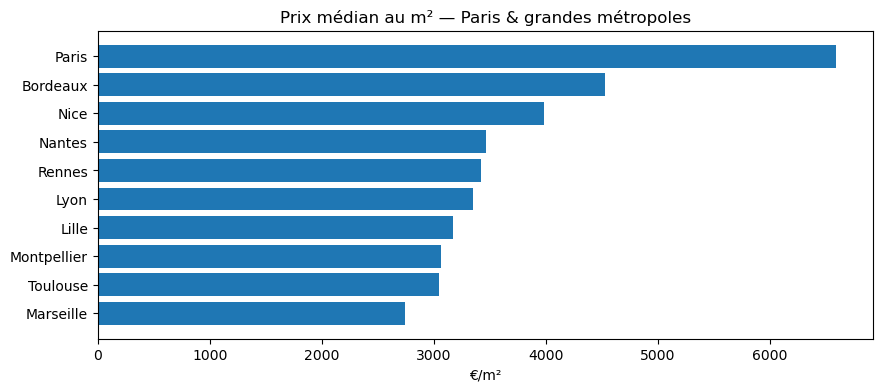

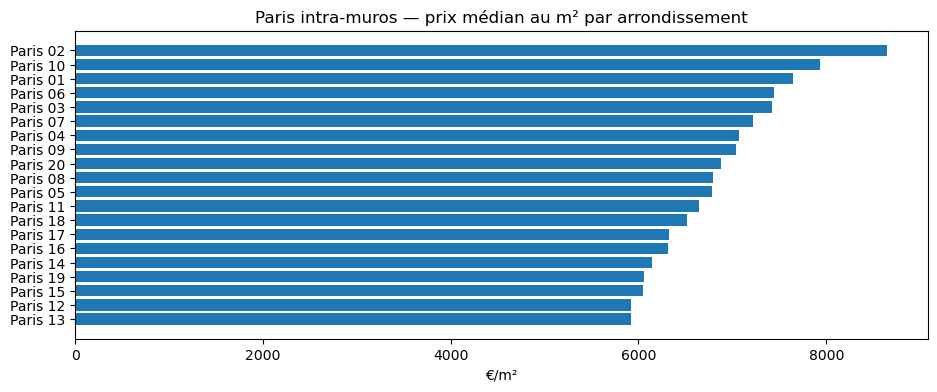

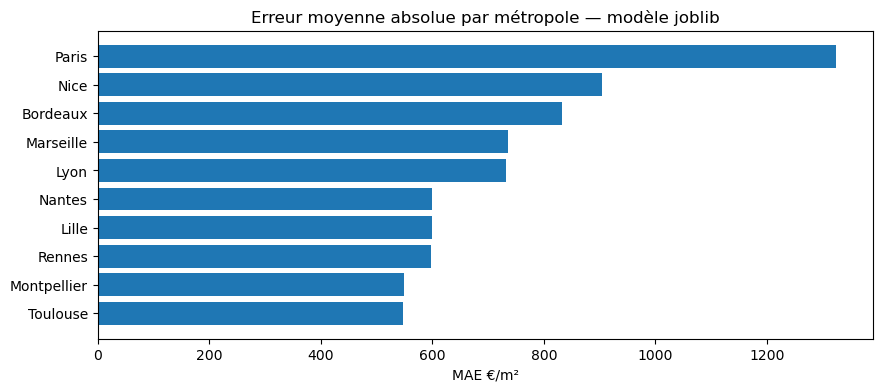

In [ ]:
# Synthèse descriptive par métropole.
# Le tableau agrège les principaux indicateurs utiles à la démonstration :
# volume, prix médian, dispersion des prix, surface médiane et variables
# socio-économiques ou financières lorsqu'elles sont disponibles.
agg_dict = {
    "transactions": (COLS["prix_m2"], "size"),
    "prix_m2_median": (COLS["prix_m2"], "median"),
    "prix_m2_q25": (
        COLS["prix_m2"],
        lambda x: pd.to_numeric(x, errors="coerce").quantile(.25),
    ),
    "prix_m2_q75": (
        COLS["prix_m2"],
        lambda x: pd.to_numeric(x, errors="coerce").quantile(.75),
    ),
    "surface_median": (COLS["surface"], "median"),
}

# Ajout conditionnel des variables complémentaires.
if COLS["revenu"]:
    agg_dict["revenu_median_reel"] = (COLS["revenu"], "median")

if COLS["taux"]:
    agg_dict["taux_median_reel"] = (COLS["taux"], "median")

if COLS["tension"]:
    agg_dict["tension_median_reelle"] = (COLS["tension"], "median")


# Construction du tableau de synthèse métropole.
metro_summary = (
    df_demo.groupby("demo_metropole")
    .agg(**agg_dict)
    .reset_index()
    .sort_values("prix_m2_median", ascending=False)
)

display(
    metro_summary.style.format(
        {
            "transactions": "{:,.0f}",
            "prix_m2_median": "{:,.0f} €/m²",
            "prix_m2_q25": "{:,.0f} €/m²",
            "prix_m2_q75": "{:,.0f} €/m²",
            "surface_median": "{:,.0f} m²",
            "revenu_median_reel": "{:,.0f} €",
            "taux_median_reel": "{:.2f}",
            "tension_median_reelle": "{:.3f}",
        }
    )
)


# Extraction de l'arrondissement à partir du libellé de commune.
# Exemple attendu : "PARIS 15" devient "Paris 15".
def paris_arrondissement_from_commune(x: str) -> str | None:
    txt = str(x).upper().strip()

    if not txt.startswith("PARIS") or txt == "PARIS":
        return None

    m = pd.Series([txt]).str.extract(r"PARIS\s+(\d{1,2})").iloc[0, 0]

    if pd.isna(m):
        return None

    try:
        arr = int(m)

        if 1 <= arr <= 20:
            return f"Paris {arr:02d}"

    except Exception:
        pass

    return None


# Normalisation du type de bien pour distinguer appartements et maisons.
def normalize_type_label(x: str) -> str | None:
    t = str(x).upper()

    if "APPART" in t:
        return "Appartement"

    if "MAISON" in t:
        return "Maison"

    return None


# Seuil minimal d'observations retenu pour considérer un croisement
# arrondissement x type comme suffisamment robuste.
PARIS_TYPE_MIN_N = 30


# Contrôle spécifique Paris par arrondissement.
paris_arr_df = df_demo[
    df_demo["demo_metropole"].eq("Paris")
].copy()

paris_arr_df["arrondissement"] = paris_arr_df[
    COLS["commune"]
].apply(paris_arrondissement_from_commune)


# Synthèse des prix par arrondissement.
paris_arr_summary = (
    paris_arr_df.dropna(subset=["arrondissement"])
    .groupby("arrondissement")
    .agg(
        transactions=(COLS["prix_m2"], "size"),
        prix_m2_median=(COLS["prix_m2"], "median"),
        prix_m2_moyen=(COLS["prix_m2"], "mean"),
    )
    .reset_index()
    .sort_values("arrondissement")
)

if not paris_arr_summary.empty:
    display(
        paris_arr_summary.style.format(
            {
                "transactions": "{:,.0f}",
                "prix_m2_median": "{:,.0f} €/m²",
                "prix_m2_moyen": "{:,.0f} €/m²",
            }
        )
    )


# Contrôle Paris par arrondissement et par type de bien.
# Le seuil de robustesse évite de commenter des croisements trop peu fournis.
paris_arr_type_df = paris_arr_df.dropna(
    subset=["arrondissement"]
).copy()

paris_arr_type_df["type_bien_paris"] = paris_arr_type_df[
    COLS["type"]
].apply(normalize_type_label)

paris_arr_type_df = paris_arr_type_df.dropna(
    subset=["type_bien_paris"]
)


# Synthèse arrondissement x type.
paris_arr_type_summary = (
    paris_arr_type_df.groupby(["arrondissement", "type_bien_paris"])
    .agg(
        transactions=(COLS["prix_m2"], "size"),
        prix_m2_median=(COLS["prix_m2"], "median"),
        prix_m2_moyen=(COLS["prix_m2"], "mean"),
    )
    .reset_index()
)

paris_arr_type_summary["robuste"] = (
    paris_arr_type_summary["transactions"] >= PARIS_TYPE_MIN_N
)


if not paris_arr_type_summary.empty:

    # Tableau complet, y compris les croisements peu fournis.
    display(
        paris_arr_type_summary
        .sort_values(
            ["type_bien_paris", "prix_m2_median"],
            ascending=[True, False],
        )
        .style.format(
            {
                "transactions": "{:,.0f}",
                "prix_m2_median": "{:,.0f} €/m²",
                "prix_m2_moyen": "{:,.0f} €/m²",
            }
        )
    )

    print(
        f"Seuil robustesse appliqué : n >= {PARIS_TYPE_MIN_N} "
        "par arrondissement x type."
    )

    # Tableau limité aux croisements suffisamment robustes.
    paris_arr_type_robuste = paris_arr_type_summary[
        paris_arr_type_summary["robuste"]
    ].copy()

    display(
        paris_arr_type_robuste
        .sort_values(
            ["type_bien_paris", "prix_m2_median"],
            ascending=[True, False],
        )
        .style.format(
            {
                "transactions": "{:,.0f}",
                "prix_m2_median": "{:,.0f} €/m²",
                "prix_m2_moyen": "{:,.0f} €/m²",
            }
        )
    )

    # Tableau pivot pour comparer directement appartements et maisons.
    paris_arr_type_pivot = paris_arr_type_robuste.pivot(
        index="arrondissement",
        columns="type_bien_paris",
        values="prix_m2_median",
    ).sort_index()

    display(
        paris_arr_type_pivot.style.format("{:,.0f} €/m²")
    )

    # Exports de traçabilité.
    paris_arr_type_summary.to_csv(
        OUTPUT_DIR / "paris_arrondissement_type_prix_m2.csv",
        index=False,
    )

    paris_arr_type_robuste.to_csv(
        OUTPUT_DIR / "paris_arrondissement_type_prix_m2_robuste_n30.csv",
        index=False,
    )


# Visualisation des prix médians par métropole.
fig, ax = plt.subplots(figsize=(10, 4))

s = metro_summary.sort_values(
    "prix_m2_median",
    ascending=True,
)

ax.barh(s["demo_metropole"], s["prix_m2_median"])
ax.set_title("Prix médian au m² — Paris & grandes métropoles")
ax.set_xlabel("€/m²")

plt.show()


# Visualisation des prix médians par arrondissement parisien.
if not paris_arr_summary.empty:

    fig, ax = plt.subplots(figsize=(11, 4))

    s_paris = paris_arr_summary.sort_values(
        "prix_m2_median",
        ascending=True,
    )

    ax.barh(s_paris["arrondissement"], s_paris["prix_m2_median"])
    ax.set_title("Paris intra-muros — prix médian au m² par arrondissement")
    ax.set_xlabel("€/m²")

    plt.show()


# Visualisation des erreurs moyennes absolues du modèle par métropole.
fig, ax = plt.subplots(figsize=(10, 4))

s = metro_eval.sort_values(
    "MAE_€/m2",
    ascending=True,
)

ax.barh(s["demo_metropole"], s["MAE_€/m2"])
ax.set_title("Erreur moyenne absolue par métropole — modèle joblib")
ax.set_xlabel("MAE €/m²")

plt.show()

## 8. Adresse → coordonnées → IRIS de référence

Le formulaire part d'une adresse. La logique est :

1. géocoder l'adresse via l'API Adresse nationale si Internet est disponible ;
2. récupérer latitude, longitude, commune et code postal ;
3. retrouver l'IRIS le plus cohérent dans le feature store par voisinage géographique ;
4. utiliser cet IRIS et les transactions proches pour construire le pool local.

Sans fichier de polygones IRIS, cette méthode ne prétend pas refaire un géocodage administratif parfait. Elle retrouve l'IRIS **observé le plus proche dans le feature store**, ce qui est suffisant pour la preuve de fonctionnement et évite de demander à l'utilisateur un code IRIS.

In [ ]:
# Géocodage d'une adresse à partir de l'API Adresse nationale.
# La fonction renvoie les coordonnées GPS ainsi que les informations
# administratives associées lorsque l'adresse est retrouvée.
def geocode_address(
    address: str,
    city: str | None = None,
    postcode: str | None = None,
) -> dict:

    # Le géocodage est désactivé si requests n'est pas disponible.
    if requests is None:
        return {
            "ok": False,
            "reason": "requests indisponible",
        }

    # Une adresse vide ne peut pas être géocodée.
    if not address or not str(address).strip():
        return {
            "ok": False,
            "reason": "adresse vide",
        }

    # Construction de la requête adressée à l'API.
    q = str(address).strip()

    # Ajout de la ville si elle n'est pas déjà présente dans l'adresse.
    if city and str(city).strip().lower() not in q.lower():
        q = f"{q}, {city}"

    # Ajout du code postal si fourni.
    if postcode and str(postcode).strip() not in q:
        q = f"{q} {postcode}"

    try:

        # Appel de l'API Adresse.
        r = requests.get(
            "https://api-adresse.data.gouv.fr/search/",
            params={
                "q": q,
                "limit": 1,
            },
            timeout=8,
        )

        r.raise_for_status()

        data = r.json()
        features = data.get("features", [])

        # Aucun résultat exploitable.
        if not features:
            return {
                "ok": False,
                "reason": "adresse non trouvée",
            }

        # Premier résultat retourné par l'API.
        f = features[0]

        lon, lat = f["geometry"]["coordinates"]
        props = f.get("properties", {})

        return {
            "ok": True,
            "query": q,
            "label": props.get("label"),
            "score": props.get("score"),
            "lat": float(lat),
            "lon": float(lon),
            "city": props.get("city"),
            "postcode": props.get("postcode"),
            "citycode": props.get("citycode"),
        }

    except Exception as e:

        return {
            "ok": False,
            "reason": str(e),
        }


# Calcul de distance géographique entre deux points.
# La formule de Haversine permet d'obtenir une distance approximative
# en kilomètres à partir de deux couples latitude / longitude.
def haversine_km(lat1, lon1, lat2, lon2):

    R = 6371.0

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [
            lat1,
            lon1,
            lat2,
            lon2,
        ],
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


# Rattachement approximatif d'une adresse géocodée au référentiel
# transactionnel disponible.
# On recherche la transaction la plus proche dans le feature store.
def infer_location_from_coordinates(
    lat,
    lon,
    metropole=None,
    max_km=3.0,
):

    # Le rattachement spatial nécessite des coordonnées dans le feature store.
    if COLS["lat"] is None or COLS["lon"] is None:
        return {
            "ok": False,
            "reason": "coordonnées absentes du feature store",
        }

    pool = df_model.copy()

    # Restriction optionnelle à une métropole donnée.
    if metropole:

        sub = pool[
            pool["demo_metropole"].eq(metropole)
        ]

        if len(sub) >= 10:
            pool = sub

    # Suppression des transactions sans coordonnées.
    pool = pool.dropna(
        subset=[
            COLS["lat"],
            COLS["lon"],
        ]
    ).copy()

    if pool.empty:
        return {
            "ok": False,
            "reason": "aucune coordonnée exploitable",
        }

    # Calcul de la distance entre l'adresse et chaque transaction.
    pool["distance_adresse_km"] = haversine_km(
        lat,
        lon,
        pool[COLS["lat"]],
        pool[COLS["lon"]],
    )

    # Transaction la plus proche.
    nearest = (
        pool.sort_values("distance_adresse_km")
        .head(1)
        .iloc[0]
    )

    dist = float(nearest["distance_adresse_km"])

    return {
        "ok": dist <= max_km,
        "reason": None if dist <= max_km else f"plus proche transaction à {dist:.2f} km",
        "distance_km": dist,
        "metropole": nearest.get("demo_metropole"),
        "commune": nearest.get(COLS["commune"]),
        "iris": nearest.get(COLS["iris"]) if COLS["iris"] else None,
        "lat": float(lat),
        "lon": float(lon),
    }


# Politique de rayon utilisée pour sélectionner des comparables.
# Le rayon est plus resserré dans les marchés urbains denses, où la valeur
# varie fortement à faible distance.
def radius_policy_km(
    metropole: str,
    mode="standard",
):

    # Mode strict : rayon réduit pour une comparaison très locale.
    if mode == "strict":

        base = {
            "Paris": 0.30,
            "Lyon": 0.40,
            "Lille": 0.40,
            "Marseille": 0.50,
        }.get(metropole, 0.60)

    # Mode standard : rayon légèrement plus large pour préserver le volume.
    else:

        base = {
            "Paris": 0.50,
            "Lyon": 0.60,
            "Lille": 0.60,
            "Marseille": 0.80,
        }.get(metropole, 1.00)

    return float(base)

## 9. Construction du bien cible et des comparables locaux

In [43]:
def mode_or_nan(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    try:
        return s.mode().iloc[0]
    except Exception:
        return s.iloc[0]


def median_or_nan(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    return float(s.median()) if len(s) else np.nan


def filter_if_enough(pool, mask, min_n, reason, steps):
    candidate = pool[mask].copy()
    if len(candidate) >= min_n:
        steps.append({"filtre": reason, "conservé": True, "n": len(candidate)})
        return candidate
    steps.append({"filtre": reason, "conservé": False, "n": len(candidate)})
    return pool


def get_reference_pool(metropole, commune, type_bien, iris, date_reference, surface=None, tolerance_pct=30, min_n=20):
    steps = []
    pool = df_model.copy()

    if metropole:
        pool = filter_if_enough(pool, pool["demo_metropole"].astype(str).eq(str(metropole)), 10, f"métropole = {metropole}", steps)
    if commune and COLS["commune"]:
        pool = filter_if_enough(pool, pool[COLS["commune"]].astype(str).eq(str(commune)), min_n, f"commune = {commune}", steps)
    if iris and COLS["iris"]:
        pool = filter_if_enough(pool, pool[COLS["iris"]].astype(str).eq(str(iris)), max(8, min_n//2), f"IRIS = {iris}", steps)
    if type_bien and COLS["type"]:
        pool = filter_if_enough(pool, pool[COLS["type"]].astype(str).eq(str(type_bien)), max(8, min_n//2), f"type = {type_bien}", steps)
    if date_reference is not None and COLS["date"]:
        mask = pool[COLS["date"]].le(pd.Timestamp(date_reference))
        pool = filter_if_enough(pool, mask, max(8, min_n//2), "antifuite temporelle", steps)
    if surface is not None and COLS["surface"]:
        mask = pd.to_numeric(pool[COLS["surface"]], errors="coerce").between(surface*(1-tolerance_pct/100), surface*(1+tolerance_pct/100))
        pool = filter_if_enough(pool, mask, max(8, min_n//2), f"surface ±{tolerance_pct}%", steps)

    return pool.copy(), pd.DataFrame(steps)


def build_feature_row_from_form(metropole, commune, type_bien, surface, pieces, has_dependance, surface_terrain, date_reference, iris=None):
    pool, steps = get_reference_pool(
        metropole=metropole, commune=commune, type_bien=type_bien, iris=iris,
        date_reference=date_reference, surface=surface, tolerance_pct=35, min_n=20,
    )

    row = {}
    for col in model_features:
        if col not in df_model.columns:
            row[col] = np.nan
            continue
        if pd.api.types.is_numeric_dtype(df_model[col]):
            row[col] = median_or_nan(pool[col])
        else:
            row[col] = mode_or_nan(pool[col])

    for c in ["surface_reference", "surface_reference_model", "surface_reelle_bati", "surface_carrez", "surface"]:
        if c in model_features:
            row[c] = surface
    for c in ["nombre_pieces_principales", "nb_pieces_total", "pieces"]:
        if c in model_features:
            row[c] = pieces
    for c in ["type_bien", "type_local", "segment_bien"]:
        if c in model_features:
            row[c] = type_bien
    for c in ["has_dependance", "presence_dependance", "a_dependance"]:
        if c in model_features:
            row[c] = float(bool(has_dependance))
    for c in ["nb_dependances", "nombre_dependances"]:
        if c in model_features:
            row[c] = 1 if has_dependance else 0
    for c in ["surface_terrain", "surface_terrain_model"]:
        if c in model_features:
            row[c] = surface_terrain

    date_reference = pd.Timestamp(date_reference)
    temporal_values = {
        "annee": date_reference.year,
        "mois": date_reference.month,
        "trimestre": int((date_reference.month - 1) // 3 + 1),
        "mois_sin": float(np.sin(2 * np.pi * date_reference.month / 12)),
        "mois_cos": float(np.cos(2 * np.pi * date_reference.month / 12)),
    }
    for c, v in temporal_values.items():
        if c in model_features:
            row[c] = v

    X = clean_feature_frame(pd.DataFrame([row]).reindex(columns=model_features))
    diagnostics = {
        "n_pool": len(pool),
        "prix_m2_median_pool": median_or_nan(pool[COLS["prix_m2"]]),
        "revenu_median_pool": median_or_nan(pool[COLS["revenu"]]) if COLS["revenu"] else np.nan,
        "taux_median_pool": median_or_nan(pool[COLS["taux"]]) if COLS["taux"] else np.nan,
        "tension_median_pool": median_or_nan(pool[COLS["tension"]]) if COLS["tension"] else np.nan,
    }
    return X, pool, diagnostics, steps


def compute_comparables(metropole, commune, type_bien, surface, pieces, date_reference, iris=None, lat=None, lon=None, rayon_km=None, tolerance_pct=30, n=30):
    rayon_km = rayon_km or radius_policy_km(metropole)
    comps, steps = get_reference_pool(metropole, commune, type_bien, iris, date_reference, surface, tolerance_pct=tolerance_pct, min_n=15)
    comps = comps.copy()
    if COLS["date"]:
        comps = comps[comps[COLS["date"]].le(pd.Timestamp(date_reference))].copy()

    if lat is not None and lon is not None and COLS["lat"] and COLS["lon"]:
        comps["distance_km"] = haversine_km(float(lat), float(lon), comps[COLS["lat"]], comps[COLS["lon"]])
        geo = comps[comps["distance_km"].le(rayon_km)].copy()
        if len(geo) >= 5:
            comps = geo
        else:
            # Fallback progressif mais borné : on évite les 3 km à Paris sauf insuffisance extrême.
            max_fallback = 1.0 if metropole == "Paris" else 2.0
            geo2 = comps[comps["distance_km"].le(max(rayon_km, max_fallback))].copy()
            if len(geo2) >= 5:
                comps = geo2
    elif COLS["lat"] and COLS["lon"]:
        lat_ref = pd.to_numeric(comps[COLS["lat"]], errors="coerce").median()
        lon_ref = pd.to_numeric(comps[COLS["lon"]], errors="coerce").median()
        comps["distance_km"] = haversine_km(lat_ref, lon_ref, comps[COLS["lat"]], comps[COLS["lon"]])
    else:
        comps["distance_km"] = np.nan

    comps["distance_surface"] = (pd.to_numeric(comps[COLS["surface"]], errors="coerce") - surface).abs() / max(surface, 1)
    comps["distance_pieces"] = (pd.to_numeric(comps[COLS["pieces"]], errors="coerce") - pieces).abs() if COLS["pieces"] else 0
    comps["age_jours"] = (pd.Timestamp(date_reference) - comps[COLS["date"]]).dt.days.clip(lower=0) if COLS["date"] else 0

    comps["score_comparabilite"] = (
        0.35 * comps["distance_surface"].rank(pct=True)
        + 0.20 * pd.Series(comps["distance_pieces"]).rank(pct=True)
        + 0.25 * pd.Series(comps["age_jours"]).rank(pct=True)
        + 0.20 * comps["distance_km"].fillna(comps["distance_km"].median()).rank(pct=True)
    )
    return comps.sort_values("score_comparabilite").head(n), steps

## 10. Intervalle de confiance empirique

La fourchette affichée n'est pas une promesse de prix. Elle combine :

- l'erreur observée du modèle sur le jeu de test ;
- la dispersion locale des comparables ;
- le nombre de comparables exploitables.

In [ ]:
# Quantiles globaux des résidus du modèle :
# écart entre le prix réel observé et le prix prédit.
GLOBAL_RESIDUAL_Q10 = float(
    np.quantile(eval_df["y_true_prix_m2"] - eval_df["y_pred_prix_m2"], 0.10)
)

GLOBAL_RESIDUAL_Q90 = float(
    np.quantile(eval_df["y_true_prix_m2"] - eval_df["y_pred_prix_m2"], 0.90)
)

# Erreur absolue moyenne globale du modèle, utilisée comme référence de repli.
GLOBAL_MAE = float(global_metrics["MAE_€/m2"])

# Dictionnaire des erreurs moyennes par métropole.
# Permet d'adapter l'incertitude au niveau de performance local du modèle.
metro_error_lookup = (
    metro_eval
    .set_index("demo_metropole")["MAE_€/m2"]
    .to_dict()
)


def prediction_interval(prix_m2_pred, comparables, metropole):
    """
    Calcule un intervalle indicatif autour d'une prédiction de prix au m².

    L'intervalle combine deux sources d'incertitude :
    - la dispersion locale des comparables disponibles ;
    - l'erreur moyenne observée du modèle dans la métropole concernée.

    Parameters
    ----------
    prix_m2_pred : float
        Prix au m² prédit par le modèle.
    comparables : pandas.DataFrame
        Transactions comparables utilisées pour apprécier la dispersion locale.
    metropole : str
        Métropole de rattachement du bien évalué.

    Returns
    -------
    tuple
        Borne basse, borne haute, score de confiance et détails de calcul.
    """

    # Extraction sécurisée des prix au m² des comparables.
    # Les valeurs non numériques sont converties en NaN puis supprimées.
    p = pd.to_numeric(
        comparables[COLS["prix_m2"]],
        errors="coerce"
    ).dropna()

    # Si le nombre de comparables est suffisant, on mesure la dispersion locale
    # par l'IQR relatif : (Q75 - Q25) / médiane.
    if len(p) >= 8:
        local_iqr = float((p.quantile(0.75) - p.quantile(0.25)) / max(p.median(), 1))
    else:
        # Valeur prudente de repli lorsque le marché local est peu documenté.
        local_iqr = 0.20

    # Encadrement de la dispersion pour éviter des intervalles trop étroits
    # ou excessivement larges.
    local_iqr = float(np.clip(local_iqr, 0.08, 0.35))

    # Erreur moyenne propre à la métropole.
    # En l'absence de donnée locale, on utilise la MAE globale.
    metro_mae = float(metro_error_lookup.get(metropole, GLOBAL_MAE))

    # Largeur de l'intervalle :
    # on retient le maximum entre la dispersion locale et l'erreur modèle locale.
    width = max(prix_m2_pred * local_iqr, metro_mae)

    # Bornes de l'intervalle, avec une borne basse non négative.
    low = max(0, prix_m2_pred - width)
    high = prix_m2_pred + width

    # Score de confiance indicatif :
    # il diminue lorsque la dispersion locale augmente
    # et lorsque le nombre de comparables est insuffisant.
    confidence = int(
        np.clip(
            88 - local_iqr * 100 - max(0, 15 - len(p)) * 1.5,
            42,
            88
        )
    )

    # Retour des bornes, du score de confiance et des détails utiles
    # pour l'explicabilité de l'estimation.
    return low, high, confidence, {
        "local_iqr": local_iqr,
        "metro_mae": metro_mae,
        "n_comparables": len(p)
    }

## 11. Carte et rendu de démonstration

In [ ]:
def build_map(comparables, target_lat, target_lon, title="Bien cible"):
    """
    Construit une carte Folium centrée sur le bien cible et ses comparables.

    Parameters
    ----------
    comparables : pandas.DataFrame
        Transactions comparables à afficher sur la carte.
    target_lat : float
        Latitude du bien cible.
    target_lon : float
        Longitude du bien cible.
    title : str, optional
        Libellé affiché pour le marqueur du bien cible.

    Returns
    -------
    folium.Map or None
        Carte Folium si les coordonnées sont disponibles, sinon None.
    """

    # Sécurité : la carte n'est construite que si Folium et les coordonnées existent.
    if folium is None or target_lat is None or target_lon is None:
        return None

    # Initialisation de la carte sur l'adresse cible.
    m = folium.Map(
        location=[float(target_lat), float(target_lon)],
        zoom_start=15,
        tiles="CartoDB positron"
    )

    # Marqueur principal du bien évalué.
    folium.Marker(
        [float(target_lat), float(target_lon)],
        tooltip=title,
        popup=f"<b>{title}</b>",
        icon=folium.Icon(color="red", icon="home", prefix="fa"),
    ).add_to(m)

    # Regroupement visuel des comparables lorsque MarkerCluster est disponible.
    cluster = MarkerCluster(name="Comparables réels").add_to(m) if MarkerCluster else m

    # Ajout des comparables disposant de coordonnées exploitables.
    for _, r in comparables.dropna(subset=[COLS["lat"], COLS["lon"]]).iterrows():
        popup = f"""
        <b>Comparable réel</b><br>
        Métropole : {r.get('demo_metropole', '')}<br>
        Commune : {r.get(COLS['commune'], '')}<br>
        IRIS : {r.get(COLS['iris'], '') if COLS['iris'] else ''}<br>
        Prix : {r.get(COLS['prix_m2'], np.nan):,.0f} €/m²<br>
        Surface : {r.get(COLS['surface'], np.nan):.0f} m²<br>
        Distance : {r.get('distance_km', np.nan):.2f} km<br>
        Date : {r.get(COLS['date'], '')}
        """.replace(",", " ")

        folium.CircleMarker(
            [r[COLS["lat"]], r[COLS["lon"]]],
            radius=5,
            fill=True,
            fill_opacity=0.65,
            tooltip=f"{r.get(COLS['prix_m2'], np.nan):,.0f} €/m²".replace(",", " "),
            popup=popup,
        ).add_to(cluster)

    # Contrôle des couches cartographiques.
    folium.LayerControl().add_to(m)

    return m


def run_valuation(
    address,
    postcode,
    metropole,
    commune_manual,
    iris_manual,
    type_bien,
    surface,
    pieces,
    has_dependance,
    surface_terrain,
    date_reference,
    rayon_mode,
    tolerance_pct
):
    """
    Exécute une valorisation complète à partir des informations saisies.

    La fonction enchaîne :
    - le géocodage de l'adresse ;
    - l'inférence du territoire de référence ;
    - la construction de la ligne de features ;
    - la prédiction du prix au m² ;
    - la recherche de comparables antifuite ;
    - la construction d'un intervalle de valorisation ;
    - l'affichage des résultats, diagnostics, graphique et carte.

    Returns
    -------
    dict
        Principaux objets produits par la valorisation.
    """

    # Nettoyage de la sortie notebook avant affichage des nouveaux résultats.
    clear_output(wait=True)

    # Normalisation de la date de référence.
    date_reference = pd.Timestamp(date_reference)

    # Géocodage de l'adresse saisie.
    geo = geocode_address(
        address,
        city=metropole,
        postcode=postcode
    )

    # Initialisation de la localisation avec les informations saisies manuellement.
    target_lat = target_lon = None
    location = {
        "metropole": metropole,
        "commune": commune_manual,
        "iris": iris_manual
    }

    # Si le géocodage réussit, les coordonnées sont utilisées pour préciser
    # la commune, la métropole et l'IRIS de rattachement.
    if geo.get("ok"):
        target_lat, target_lon = geo["lat"], geo["lon"]

        inferred = infer_location_from_coordinates(
            target_lat,
            target_lon,
            metropole=metropole,
            max_km=3.0
        )

        if inferred.get("ok"):
            location.update({
                "metropole": inferred.get("metropole") or metropole,
                "commune": inferred.get("commune") or commune_manual,
                "iris": inferred.get("iris") or iris_manual,
            })

    # Si le géocodage échoue, on conserve les informations déclaratives.
    else:
        inferred = {
            "ok": False,
            "reason": geo.get("reason")
        }

    # Détermination du rayon de recherche adapté à la métropole et au mode choisi.
    rayon_km = radius_policy_km(
        location["metropole"],
        mode=rayon_mode
    )

    # Construction de la ligne d'entrée modèle et du pool de contexte.
    X_input, pool, diag, pool_steps = build_feature_row_from_form(
        metropole=location["metropole"],
        commune=location["commune"],
        type_bien=type_bien,
        surface=surface,
        pieces=pieces,
        has_dependance=has_dependance,
        surface_terrain=surface_terrain,
        date_reference=date_reference,
        iris=location["iris"],
    )

    # Prédiction du modèle en log-prix, puis retour en prix au m².
    pred_log = float(pipeline.predict(X_input)[0])
    prix_m2_pred = float(np.exp(pred_log))

    # Valorisation totale estimée.
    valeur_pred = prix_m2_pred * surface

    # Recherche des comparables réels disponibles avant la date de référence.
    comparables, comp_steps = compute_comparables(
        metropole=location["metropole"],
        commune=location["commune"],
        type_bien=type_bien,
        surface=surface,
        pieces=pieces,
        date_reference=date_reference,
        iris=location["iris"],
        lat=target_lat,
        lon=target_lon,
        rayon_km=rayon_km,
        tolerance_pct=tolerance_pct,
        n=30,
    )

    # Construction de l'intervalle empirique autour de la prédiction.
    low, high, confiance, interval_diag = prediction_interval(
        prix_m2_pred,
        comparables,
        location["metropole"]
    )

    # Conversion de l'intervalle en valeur totale.
    valeur_low = low * surface
    valeur_high = high * surface

    # Bloc de synthèse principal affiché dans le notebook.
    display(HTML(f"""
    <div style="font-family:Arial; padding:18px; border-radius:16px; border:1px solid #d9e2ec; background:#f8fafc;">
      <h2 style="margin:0 0 8px 0; color:#0b1f4d;">Valorisation immobilière augmentée — démo v4</h2>
      <div style="font-size:26px; margin:6px 0;"><b>{prix_m2_pred:,.0f} €/m²</b> — <b>{valeur_pred:,.0f} €</b></div>
      <div>Fourchette empirique : <b>{low:,.0f} à {high:,.0f} €/m²</b>, soit <b>{valeur_low:,.0f} à {valeur_high:,.0f} €</b></div>
      <div>Confiance indicative : <b>{confiance} %</b> · comparables retenus : <b>{len(comparables)}</b> · rayon : <b>{rayon_km:.2f} km</b></div>
      <hr>
      <div><b>Adresse saisie :</b> {address}</div>
      <div><b>Adresse reconnue :</b> {geo.get('label', 'non géocodée')} — score : {geo.get('score', np.nan)}</div>
      <div><b>Territoire de référence :</b> {location['metropole']} · {location['commune']} · IRIS {location['iris']}</div>
    </div>
    """.replace(",", " ")))

    # Affichage des métriques globales du modèle.
    display(HTML("<h3>Performance du modèle affichée pendant la démo</h3>"))
    display(pd.DataFrame([global_metrics]).style.format({
        "MAE_€/m2": "{:,.0f}",
        "RMSE_€/m2": "{:,.0f}",
        "R2_log": "{:.3f}",
        "R2_prix_m2": "{:.3f}",
    }))

    # Diagnostic territorial ayant servi à la prédiction.
    display(HTML("<h3>Diagnostic du territoire homogène utilisé</h3>"))
    display(pd.DataFrame([
        {"indicateur": "Métropole", "valeur": location["metropole"]},
        {"indicateur": "Commune", "valeur": location["commune"]},
        {"indicateur": "IRIS", "valeur": location["iris"]},
        {"indicateur": "Pool de contexte", "valeur": diag["n_pool"]},
        {"indicateur": "Prix m² médian du pool", "valeur": diag["prix_m2_median_pool"]},
        {"indicateur": "MAE métropole utilisée", "valeur": interval_diag["metro_mae"]},
        {"indicateur": "Dispersion locale IQR", "valeur": interval_diag["local_iqr"]},
    ]))

    # Traçabilité des filtres appliqués pour construire le pool de contexte.
    display(HTML("<h3>Filtres réellement conservés pour construire le pool</h3>"))
    display(pool_steps)

    # Affichage des transactions comparables retenues.
    display(HTML("<h3>Comparables réels antifuite</h3>"))
    display_cols = [
        c for c in [
            COLS["date"],
            "demo_metropole",
            COLS["commune"],
            COLS["iris"],
            COLS["type"],
            COLS["surface"],
            COLS["pieces"],
            COLS["prix_m2"],
            "distance_km",
            "score_comparabilite"
        ]
        if c and c in comparables.columns
    ]
    display(comparables[display_cols].head(30))

    # Graphique de positionnement du bien cible dans son micro-marché.
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(
        comparables[COLS["surface"]],
        comparables[COLS["prix_m2"]],
        alpha=0.65,
        label="Comparables réels"
    )
    ax.axhline(prix_m2_pred, linestyle="--", label="Prédiction modèle")
    ax.axvline(surface, linestyle=":", label="Surface cible")
    ax.set_title("Positionnement du bien cible dans son micro-marché")
    ax.set_xlabel("Surface")
    ax.set_ylabel("Prix au m²")
    ax.legend()
    plt.show()

    # Affichage de la carte uniquement lorsque les coordonnées sont disponibles.
    if target_lat is not None and target_lon is not None:
        m = build_map(
            comparables,
            target_lat,
            target_lon,
            title="Adresse cible"
        )

        if m is not None:
            display(m)

    # Retour des principaux résultats pour réutilisation éventuelle.
    return {
        "geo": geo,
        "location": location,
        "prix_m2_pred": prix_m2_pred,
        "valeur_pred": valeur_pred,
        "comparables": comparables,
    }

## 12. Formulaire interactif v4

Le formulaire est volontairement orienté utilisateur : on saisit une adresse, puis le notebook retrouve le contexte territorial.

In [46]:
types = sorted(df_model[COLS["type"]].dropna().astype(str).unique().tolist())
metropoles = [m for m in TARGET_METROPOLES if m in df_model["demo_metropole"].unique()]
default_date = pd.Timestamp(df_model[COLS["date"]].max()).date() if COLS["date"] else pd.Timestamp.today().date()

if widgets is None:
    print("ipywidgets n'est pas disponible. Appeler directement run_valuation(...).")
else:
    style = {"description_width": "150px"}
    wide = Layout(width="760px")
    half = Layout(width="370px")

    address_w = widgets.Text(
        value="10 avenue Victor Hugo",
        description="Adresse",
        placeholder="Ex. 10 avenue Victor Hugo",
        style=style,
        layout=wide,
    )
    postcode_w = widgets.Text(
        value="75116",
        description="Code postal",
        style=style,
        layout=half,
    )
    metropole_w = widgets.Dropdown(
        options=metropoles,
        value="Paris" if "Paris" in metropoles else metropoles[0],
        description="Métropole",
        style=style,
        layout=half,
    )
    commune_w = widgets.Dropdown(options=[], description="Commune fallback", style=style, layout=half)
    iris_w = widgets.Dropdown(options=[""], description="IRIS fallback", style=style, layout=half)
    type_w = widgets.Dropdown(options=types, value=types[0], description="Type de bien", style=style, layout=half)
    surface_w = widgets.BoundedFloatText(value=80, min=5, max=500, step=1, description="Surface m²", style=style, layout=half)
    pieces_w = widgets.BoundedIntText(value=3, min=1, max=20, description="Nb pièces", style=style, layout=half)
    dep_w = widgets.Checkbox(value=False, description="Dépendance", indent=False, layout=half)
    terrain_w = widgets.BoundedFloatText(value=0, min=0, max=5000, step=5, description="Terrain m²", style=style, layout=half)
    date_w = widgets.DatePicker(value=default_date, description="Date référence", style=style, layout=half)
    rayon_mode_w = widgets.ToggleButtons(options=[("Standard", "standard"), ("Strict", "strict")], value="standard", description="Rayon", style=style)
    tolerance_w = widgets.IntSlider(value=30, min=10, max=60, step=5, description="Tolérance surface", style=style, layout=wide)
    run_button = widgets.Button(description="Lancer la valorisation", button_style="primary", icon="calculator", layout=Layout(width="250px"))
    out = widgets.Output()

    def update_communes(*args):
        sub = df_model[df_model["demo_metropole"].eq(metropole_w.value)]
        communes = sorted(sub[COLS["commune"]].dropna().astype(str).unique().tolist())
        commune_w.options = communes
        if communes:
            preferred = next((c for c in communes if c == "PARIS" or c.startswith("PARIS ")), communes[0])
            commune_w.value = preferred if metropole_w.value == "Paris" else communes[0]
        update_iris()

    def update_iris(*args):
        sub = df_model[df_model["demo_metropole"].eq(metropole_w.value)]
        if commune_w.value and COLS["commune"]:
            sub = sub[sub[COLS["commune"]].astype(str).eq(str(commune_w.value))]
        iris_values = [""]
        if COLS["iris"]:
            iris_values += sorted(sub[COLS["iris"]].dropna().astype(str).unique().tolist())[:300]
        iris_w.options = iris_values
        iris_w.value = ""

    metropole_w.observe(update_communes, names="value")
    commune_w.observe(update_iris, names="value")
    update_communes()

    def on_run_clicked(_):
        with out:
            result = run_valuation(
                address=address_w.value,
                postcode=postcode_w.value,
                metropole=metropole_w.value,
                commune_manual=commune_w.value,
                iris_manual=iris_w.value,
                type_bien=type_w.value,
                surface=float(surface_w.value),
                pieces=int(pieces_w.value),
                has_dependance=bool(dep_w.value),
                surface_terrain=float(terrain_w.value),
                date_reference=date_w.value,
                rayon_mode=rayon_mode_w.value,
                tolerance_pct=int(tolerance_w.value),
            )
            globals()["last_demo_result"] = result

    run_button.on_click(on_run_clicked)

    form = VBox([
        widgets.HTML("<h3>Formulaire de valorisation — adresse vers IRIS</h3>"),
        address_w,
        HBox([postcode_w, metropole_w]),
        HBox([commune_w, iris_w]),
        HBox([type_w, surface_w]),
        HBox([pieces_w, terrain_w]),
        HBox([dep_w, date_w]),
        rayon_mode_w,
        tolerance_w,
        run_button,
        out,
    ])
    display(form)
    print("Si l'interface ne s'affiche pas visuellement et que vous voyez VBox(...), réactiver l'affichage des widgets du notebook puis réexécuter cette cellule.")

Si l'interface ne s'affiche pas visuellement et que vous voyez VBox(...), réactiver l'affichage des widgets du notebook puis réexécuter cette cellule.


## 13. Audit des comparables par métropole

Ce contrôle permet de conclure sur le caractère pratique du travail : on vérifie si chaque métropole dispose d'un nombre suffisant de comparables locaux avec le rayon retenu.

,metropole,rayon_standard_km,nb_moyen_comparables,nb_median_comparables,pct_cas_5_plus,observations_testees
6,Montpellier,1.00,24.2,29.5,98%,40
2,Lyon,0.60,24.0,30.0,100%,40
4,Nice,1.00,24.0,30.0,98%,40
1,Marseille,0.80,23.6,30.0,98%,40
5,Nantes,1.00,23.4,30.0,98%,40
7,Bordeaux,1.00,22.8,29.0,98%,40
3,Toulouse,1.00,21.5,30.0,98%,40
9,Rennes,1.00,21.4,29.0,90%,40
8,Lille,0.60,21.1,25.5,92%,40
0,Paris,0.50,21.1,23.0,92%,40


,Métropole,R²,MAE,Comparables moyens
0,Rennes,0.703,598,21.4
1,Toulouse,0.686,548,21.5
2,Montpellier,0.657,549,24.2
3,Nantes,0.647,599,23.4
4,Lyon,0.618,732,24.0
5,Nice,0.611,904,24.0
6,Marseille,0.602,735,23.6
7,Lille,0.594,599,21.1
8,Paris,0.544,"1,323",21.1
9,Bordeaux,0.393,833,22.8


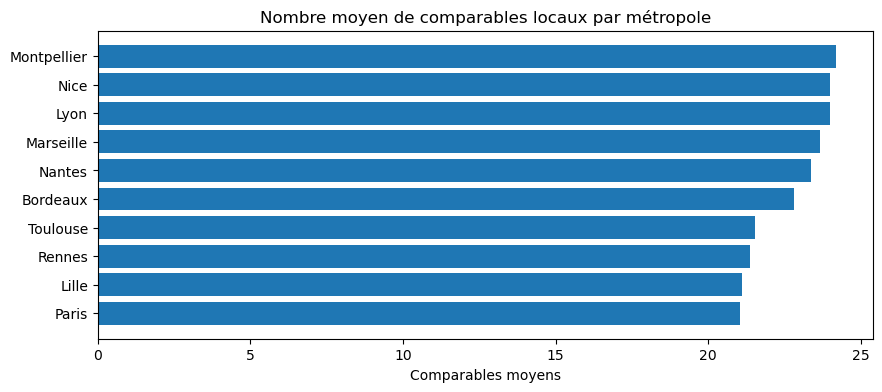

In [61]:
def comparable_capacity_audit(sample_per_metro=50):
    rows = []
    rng = np.random.default_rng(RANDOM_STATE)
    for metro in metropoles:
        sub = df_model[df_model["demo_metropole"].eq(metro)].copy()
        if sub.empty:
            continue
        sample = sub.sample(min(sample_per_metro, len(sub)), random_state=RANDOM_STATE)
        radius = radius_policy_km(metro, mode="standard")
        counts = []
        for _, r in sample.iterrows():
            lat = r.get(COLS["lat"]) if COLS["lat"] else None
            lon = r.get(COLS["lon"]) if COLS["lon"] else None
            surface = float(r.get(COLS["surface"], np.nan)) if pd.notna(r.get(COLS["surface"], np.nan)) else 70
            pieces = int(r.get(COLS["pieces"], 3)) if COLS["pieces"] and pd.notna(r.get(COLS["pieces"], np.nan)) else 3
            comps, _ = compute_comparables(
                metropole=metro,
                commune=r.get(COLS["commune"]),
                type_bien=r.get(COLS["type"]),
                surface=surface,
                pieces=pieces,
                date_reference=r.get(COLS["date"], pd.Timestamp.today()) if COLS["date"] else pd.Timestamp.today(),
                iris=r.get(COLS["iris"]) if COLS["iris"] else None,
                lat=lat,
                lon=lon,
                rayon_km=radius,
                tolerance_pct=30,
                n=30,
            )
            counts.append(len(comps))
        rows.append({
            "metropole": metro,
            "rayon_standard_km": radius,
            "nb_moyen_comparables": float(np.mean(counts)) if counts else np.nan,
            "nb_median_comparables": float(np.median(counts)) if counts else np.nan,
            "pct_cas_5_plus": float(np.mean(np.array(counts) >= 5)) if counts else np.nan,
            "observations_testees": len(counts),
        })
    return pd.DataFrame(rows).sort_values("nb_moyen_comparables", ascending=False)

comparable_audit = comparable_capacity_audit(sample_per_metro=40)
display(comparable_audit.style.format({
    "rayon_standard_km": "{:.2f}", "nb_moyen_comparables": "{:.1f}",
    "nb_median_comparables": "{:.1f}", "pct_cas_5_plus": "{:.0%}",
}))

# Tableau de démonstration demandé : métropole / R² / MAE / comparables moyens.
tableau_demo = metro_eval[["demo_metropole", "R2_prix_m2", "MAE_€/m2"]].rename(
    columns={"demo_metropole": "metropole"}
).merge(
    comparable_audit[["metropole", "nb_moyen_comparables"]],
    on="metropole",
    how="left"
).sort_values("R2_prix_m2", ascending=False).reset_index(drop=True)

tableau_executif_metropoles = tableau_demo.rename(columns={
    "metropole": "Métropole",
    "R2_prix_m2": "R²",
    "MAE_€/m2": "MAE",
    "nb_moyen_comparables": "Comparables moyens",
}).copy()

display(tableau_executif_metropoles.style.format({
    "R²": "{:.3f}",
    "MAE": "{:,.0f}",
    "Comparables moyens": "{:.1f}",
}))

tableau_demo.to_csv(OUTPUT_DIR / "tableau_demo_metropole_r2_mae_comparables.csv", index=False)
tableau_executif_metropoles.to_csv(OUTPUT_DIR / "tableau_executif_metropoles_final.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
s = comparable_audit.sort_values("nb_moyen_comparables", ascending=True)
ax.barh(s["metropole"], s["nb_moyen_comparables"])
ax.set_title("Nombre moyen de comparables locaux par métropole")
ax.set_xlabel("Comparables moyens")
plt.show()

## 14. Exports v4

Ces fichiers peuvent alimenter une future application Streamlit ou la documentation du portfolio GitHub.

,source_modele,split_evaluation,periode_dvf,n_test,n_features,MAE_€/m2,RMSE_€/m2,R2_log,R2_prix_m2
0,joblib notebook 12,test temporel année 2025,2021-01-04 -> 2025-12-31,79444,82,891,"1,307",0.766,0.747


,indicateur,valeur
0,Métropole,Paris
1,Commune,PARIS 16E ARRONDISSEMENT
2,IRIS,751166409
3,Pool de contexte,39
4,Prix m² médian du pool,6800.377289
5,MAE métropole utilisée,1324.07056
6,Dispersion locale IQR,0.35


,filtre,conservé,n
0,métropole = Paris,True,120776
1,commune = PARIS 16E ARRONDISSEMENT,True,9034
2,IRIS = 751166409,True,163
3,type = Appartement,True,163
4,antifuite temporelle,True,163
5,surface ±35%,True,39


,date_mutation,demo_metropole,nom_commune,code_iris,type_bien,surface_reference,nb_pieces_total,prix_m2_from_log,distance_km,score_comparabilite
3247071,2025-09-23,Paris,PARIS 16E ARRONDISSEMENT,751166409,Appartement,76.88,4.0,9431.280957,0.078062,0.171429
2559415,2024-04-22,Paris,PARIS 16E ARRONDISSEMENT,751166409,Appartement,84.43,3.0,10364.614829,0.130089,0.235714
426039,2021-06-01,Paris,PARIS 16E ARRONDISSEMENT,751166409,Appartement,84.54,3.0,11117.631181,0.045822,0.310714
2564684,2024-09-25,Paris,PARIS 16E ARRONDISSEMENT,751166409,Appartement,85.28,2.0,5876.938086,0.218672,0.350000
2565974,2024-10-10,Paris,PARIS 16E ARRONDISSEMENT,751166409,Appartement,66.00,3.0,7955.545455,0.086243,0.366071
1957777,2023-12-01,Paris,PARIS 16E ARRONDISSEMENT,751166409,Appartement,80.04,3.0,5018.491254,0.183290,0.373214
2562804,2024-07-25,Paris,PARIS 16E ARRONDISSEMENT,751166409,Appartement,86.76,2.0,6397.957123,0.219357,0.410714
3247524,2025-10-14,Paris,PARIS 16E ARRONDISSEMENT,751166409,Appartement,100.00,2.0,3992.500000,0.120791,0.423214
3250045,2025-12-18,Paris,PARIS 16E ARRONDISSEMENT,751166409,Appartement,59.82,3.0,8359.408559,0.157891,0.508929
425476,2021-02-05,Paris,PARIS 16E ARRONDISSEMENT,751166409,Appartement,75.36,3.0,11280.193206,0.137390,0.512500


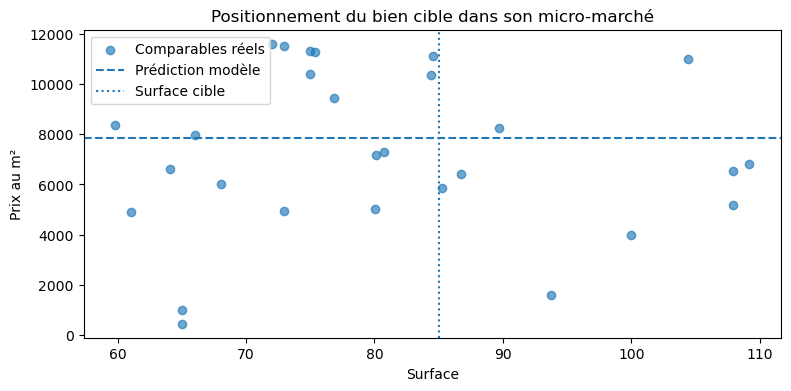

,adresse,metropole_retendue,commune_retendue,iris_retenu,prix_m2_estime,valeur_estimee,nb_comparables
0,"10 avenue Victor Hugo, Paris 16",Paris,PARIS 16E ARRONDISSEMENT,751166409,"7,860 €/m²","668,127 €",28


In [ ]:

# Cas d'usage de démonstration

# Scénario standardisé utilisé lors de la soutenance afin de présenter
# l'ensemble de la chaîne de valorisation dans un contexte reproductible.
# L'adresse est volontairement fixe afin de faciliter les comparaisons
# entre différentes exécutions du modèle.

story_result = run_valuation(
    address="10 avenue Victor Hugo",
    postcode="75116",
    metropole="Paris",
    commune_manual="PARIS 16",
    iris_manual="",
    type_bien="Appartement" if "Appartement" in types else types[0],
    surface=85.0,
    pieces=4,
    has_dependance=False,
    surface_terrain=0.0,
    date_reference=default_date,
    rayon_mode="strict",
    tolerance_pct=30,
)


# Synthèse de la valorisation

# Tableau récapitulatif des principaux résultats produits par le moteur
# d'estimation : territoire retenu, prix prédit, valeur estimée et nombre
# de comparables effectivement mobilisés.

story_summary = pd.DataFrame([{
    "adresse": "10 avenue Victor Hugo, Paris 16",
    "metropole_retendue": story_result["location"].get("metropole"),
    "commune_retendue": story_result["location"].get("commune"),
    "iris_retenu": story_result["location"].get("iris"),
    "prix_m2_estime": story_result["prix_m2_pred"],
    "valeur_estimee": story_result["valeur_pred"],
    "nb_comparables": len(story_result["comparables"]),
}])

# Affichage de la synthèse avec mise en forme des valeurs monétaires.
display(
    story_summary.style.format({
        "prix_m2_estime": "{:,.0f} €/m²",
        "valeur_estimee": "{:,.0f} €",
        "nb_comparables": "{:,.0f}",
    })
)

## 14 bis. Cas d'usage complet (storytelling)

Scénario démonstrateur prêt soutenance :

- adresse : Avenue Victor Hugo, Paris 16 ;
- géocodage puis inférence IRIS locale ;
- constitution des comparables antifuite ;
- estimation et intervalle empirique ;
- rendu carte + tableau comparables.

In [ ]:

# Export des principaux résultats de la démonstration

# Les fichiers générés permettent de conserver une trace des indicateurs
# utilisés pendant la soutenance et facilitent les analyses ultérieures.

# Synthèse descriptive des marchés par métropole.
metro_summary.to_csv(
    OUTPUT_DIR / "synthese_marche_par_metropole_v4.csv",
    index=False
)

# Performances du modèle calculées pour chaque métropole.
metro_eval.to_csv(
    OUTPUT_DIR / "performance_modele_par_metropole_v4.csv",
    index=False
)

# Audit des comparables réellement mobilisés lors des valorisations.
comparable_audit.to_csv(
    OUTPUT_DIR / "audit_comparables_par_metropole_v4.csv",
    index=False
)

# Indicateurs globaux de performance du modèle.
pd.DataFrame([global_metrics]).to_csv(
    OUTPUT_DIR / "performance_globale_modele_v4.csv",
    index=False
)

# Liste des variables effectivement utilisées par le modèle entraîné.
pd.DataFrame({"feature": model_features}).to_csv(
    OUTPUT_DIR / "features_modele_joblib_v4.csv",
    index=False
)

# Confirmation de la génération des exports.
print("Exports v4 disponibles dans :", OUTPUT_DIR.resolve())

Exports v4 disponibles dans : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\demo_paris_metropoles


## 15. Conclusion métier attendue

La démonstration v4 apporte trois preuves :

1. **preuve modèle** : le modèle entraîné et sauvegardé par le notebook 12 est réutilisé tel quel ;
2. **preuve territoriale** : l'utilisateur saisit une adresse, le notebook retrouve le contexte local homogène et évite les comparables trop éloignés ;
3. **preuve pratique** : le résultat est compréhensible avec prix au m², fourchette, comparables, carte, R², MAE et comportement par métropole.

Cette restitution doit être présentée comme une **preuve de fonctionnement robuste du pipeline sur données DVF enrichies**, et non comme une “vérité marché” exhaustive.

La limite principale reste connue et saine : sans polygones IRIS officiels embarqués, l'IRIS est inféré depuis les transactions géocodées du feature store. Pour une version production, il faudra ajouter une table géographique IRIS officielle et faire un vrai point-dans-polygone.

## 15 bis. Limites méthodologiques et pistes futures

### Données DVF et enrichissements
- Les données DVF restent observationnelles : erreurs de saisie, hétérogénéité territoriale, temporalité irrégulière.
- Certains champs utiles à l'audit complet (valeur foncière brute, identifiant mutation) peuvent manquer selon les versions de feature store.

### Biais connus
- Biais de sélection spatiale : les zones très denses sont mieux couvertes en comparables.
- Biais de composition : mélange possible de sous-segments fins (qualité du bien, étage, état réel non observé).
- Biais temporel : changement de régime de marché entre périodes, même avec variables temporelles.

### Limites actuelles
- L'IRIS peut être inféré par proximité des transactions et non par point-dans-polygone administratif.
- L'intervalle fourni est empirique et dépend de la qualité des comparables disponibles localement.
- La variable tension doit rester surveillée si sa distribution se concentre sur trop peu de valeurs.

### Pistes futures
- Intégrer les polygones IRIS officiels pour un rattachement géographique strict.
- Ajouter des contrôles de dérive mensuelle et recalibrage périodique des métriques par métropole.
- Enrichir les signaux micro (qualité du bâti, étage, performance énergétique) si disponibilité réglementaire.
- Produire une calibration d'incertitude dédiée (quantile regression / conformal prediction).

In [ ]:

# Synthèse de validation pour la soutenance

# Cette table rassemble les principaux éléments permettant de démontrer que
# la chaîne complète de valorisation fonctionne correctement :
# - réutilisation des artefacts issus des notebooks précédents ;
# - performances du modèle ;
# - couverture territoriale ;
# - qualité des comparables ;
# - génération des fichiers d'export.

soutenance_rows = []


# Localisation des principaux artefacts de la chaîne de traitement.


source_modele = (
    str(PATHS.get("model"))
    if "PATHS" in globals()
    else "non disponible"
)

source_synthese_13 = (
    str(PATHS.get("synthese_13"))
    if "PATHS" in globals() and PATHS.get("synthese_13")
    else "non trouvée"
)

source_dataset = (
    str(PATHS.get("dataset"))
    if "PATHS" in globals()
    else "non disponible"
)


# Récupération des indicateurs globaux de performance du modèle.


mae = (
    float(global_metrics.get("MAE_€/m2", np.nan))
    if "global_metrics" in globals()
    else np.nan
)

rmse = (
    float(global_metrics.get("RMSE_€/m2", np.nan))
    if "global_metrics" in globals()
    else np.nan
)

r2_log = (
    float(global_metrics.get("R2_log", np.nan))
    if "global_metrics" in globals()
    else np.nan
)

r2_prix = (
    float(global_metrics.get("R2_prix_m2", np.nan))
    if "global_metrics" in globals()
    else np.nan
)

n_test = (
    int(global_metrics.get("n_test", 0))
    if "global_metrics" in globals()
    else 0
)


# Indicateurs de couverture territoriale et de qualité des comparables.


n_metro = (
    int(len(metro_summary))
    if "metro_summary" in globals()
    else 0
)

missing_metro_list = (
    ", ".join(missing_metro)
    if "missing_metro" in globals() and missing_metro
    else "aucune"
)

mean_comps = (
    float(comparable_audit["nb_moyen_comparables"].mean())
    if "comparable_audit" in globals() and not comparable_audit.empty
    else np.nan
)

pct_cas_5_plus = (
    float(comparable_audit["pct_cas_5_plus"].mean())
    if "comparable_audit" in globals() and not comparable_audit.empty
    else np.nan
)


# Construction de la synthèse destinée à la démonstration.


soutenance_rows.append({
    "axe": "Chaîne des artefacts",
    "message": "Le notebook 14 recharge les sorties officielles de la chaîne 11-12-13.",
    "preuve": (
        f"Dataset: {source_dataset} | "
        f"Modèle: {source_modele} | "
        f"Synthèse13: {source_synthese_13}"
    ),
})

soutenance_rows.append({
    "axe": "Performance du modèle réutilisé",
    "message": "Le modèle final sauvegardé par le notebook 12 est exécuté tel quel.",
    "preuve": (
        f"n_test={n_test:,} | "
        f"MAE={mae:,.1f} €/m² | "
        f"RMSE={rmse:,.1f} €/m² | "
        f"R2_log={r2_log:.3f} | "
        f"R2_prix_m2={r2_prix:.3f}"
    ),
})

soutenance_rows.append({
    "axe": "Couverture territoriale",
    "message": "La démonstration couvre Paris et les principales métropoles disponibles.",
    "preuve": (
        f"Métropoles couvertes={n_metro} | "
        f"Absentes={missing_metro_list}"
    ),
})

soutenance_rows.append({
    "axe": "Solidité des comparables locaux",
    "message": "Le moteur de comparables reste exploitable après recentrage urbain.",
    "preuve": (
        f"Comparables moyens={mean_comps:.1f} | "
        f"Taux de cas ≥5 comparables={pct_cas_5_plus:.0%}"
    ),
})

# Vérification de la présence des exports produits par le notebook.


exports_expected = [
    OUTPUT_DIR / "synthese_marche_par_metropole_v4.csv",
    OUTPUT_DIR / "performance_modele_par_metropole_v4.csv",
    OUTPUT_DIR / "audit_comparables_par_metropole_v4.csv",
    OUTPUT_DIR / "performance_globale_modele_v4.csv",
    OUTPUT_DIR / "features_modele_joblib_v4.csv",
]

exports_found = sum(p.exists() for p in exports_expected)

soutenance_rows.append({
    "axe": "Exports prêts application",
    "message": "Les fichiers nécessaires à la documentation et à Streamlit sont générés.",
    "preuve": (
        f"Fichiers présents : "
        f"{exports_found}/{len(exports_expected)} dans {OUTPUT_DIR}"
    ),
})


# Création, affichage et export de la synthèse finale.


soutenance_table = pd.DataFrame(soutenance_rows)

display(soutenance_table)

soutenance_path = OUTPUT_DIR / "synthese_vitrine_soutenance_v4.csv"

soutenance_table.to_csv(
    soutenance_path,
    index=False
)

print("Résumé soutenance exporté :", soutenance_path)

,axe,message,preuve
0,Chaîne des artefacts,Le notebook 14 recharge les sorties officielle...,Dataset: C:\Users\club_\OneDrive\13_DOCUMENT\S...
1,Performance du modèle réutilisé,Le modèle final sauvegardé par le notebook 12 ...,"n_test=79,444 | MAE=891.2 €/m² | RMSE=1,307.5 ..."
2,Couverture territoriale,La démo couvre Paris et les grandes métropoles...,Métropoles couvertes=10 | Absentes=Strasbourg
3,Solidité des comparables locaux,Le moteur de comparables locaux reste exploita...,Comparables moyens=22.7 | Taux de cas >=5 comp...
4,Exports prêts application,Les sorties standards pour documentation/Strea...,Fichiers présents: 5/5 dans C:\Users\club_\One...


Résumé soutenance exporté : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\outputs\demo_paris_metropoles\synthese_vitrine_soutenance_v4.csv
